# Dimensionality & Unidimensionality Check (Author Items)

Input directory is chosen from `scripts/config.json` → `SAMPLE_VERSION`:
- **`full`** → `data/stepwise_cleaned_versions/05_dimensionality_inputs/` (full cleaned sample; larger N).
- **Other tags (e.g. `strict_fa`)** → `data/stepwise_cleaned_versions_<tag>/` and then `05_dimensionality_inputs` if present, otherwise `03_dimensionality_inputs/` (strict false-alarm sample; **688 participants** in the current export).

Files (same names in either folder):
- `ART_pretest_(for Castano)_EN__dimensionality_input__author_response_matrix.csv` — binary 0/1 matrix (N × 98 author items)
- `ART_pretest_(for Castano)_EN__dimensionality_input__author_item_key.csv` — item metadata (labels, genres, flags, cITC)
- `ART_pretest_(for Castano)_EN__dimensionality_input__foil_response_matrix.csv` — foil responses (secondary diagnostic)
- `ART_pretest_(for Castano)_EN__dimensionality_input__manifest.csv` — provenance metadata

Goals:
1. **Exploratory dimensionality check**: tetrachoric correlations, eigenvalue decomposition, scree plot with parallel analysis, exploratory factor analysis (1- and 2-factor solutions)
2. **Confirmatory unidimensionality check**: one-factor CFA with `lavaan` (WLSMV estimator for binary indicators), reporting RMSEA, CFI, TLI, SRMR, and standardized loadings
3. **Decision**: determine whether author items are sufficiently unidimensional to justify a unidimensional IRT model

References:
- Moore & Gordon (2015): explored factor structure, treated cleaned ART as practically unidimensional, noted secondary factor driven partly by rare items and guessing
- McCarron & Kuperman (2022): used one-factor CFA, accepted fit as adequate, then proceeded to 2PL IRT models

In [1]:
# IRkernel uses ZMQ sockets that break on fork(). Disable parallel forking globally.
options(mc.cores = 1)
Sys.setenv(MC_CORES = "1")

library(psych)
library(mirt)
library(lavaan)
library(corrplot)
library(ggplot2)
library(jsonlite)

cat("R version:", paste0(R.version$major, ".", R.version$minor), "\n")
cat("mc.cores:", getOption("mc.cores"), "(forced serial for IRkernel compatibility)\n")
cat("Package versions:\n")
for (p in c("psych", "mirt", "lavaan", "corrplot", "ggplot2", "jsonlite")) {
  cat(sprintf("  %-12s %s\n", p, as.character(packageVersion(p))))
}

Loading required package: stats4

Loading required package: lattice

This is lavaan 0.6-21
lavaan is FREE software! Please report any bugs.


Attaching package: ‘lavaan’


The following object is masked from ‘package:psych’:

    cor2cov


corrplot 0.95 loaded


Attaching package: ‘ggplot2’


The following objects are masked from ‘package:psych’:

    %+%, alpha




R version: 4.5.3 
mc.cores: 1 (forced serial for IRkernel compatibility)
Package versions:
  psych        2.6.3
  mirt         1.46.1
  lavaan       0.6.21
  corrplot     0.95
  ggplot2      4.0.2
  jsonlite     2.0.0


In [2]:
PROJECT_ROOT <- normalizePath(file.path("..", ".."), mustWork = TRUE)

config <- fromJSON(file.path(PROJECT_ROOT, "scripts", "config.json"))
SAMPLE_VERSION <- config$SAMPLE_VERSION
RESULTS_TAG <- if (SAMPLE_VERSION == "full") "" else paste0("_", SAMPLE_VERSION)

if (SAMPLE_VERSION == "full") {
  DATA_DIR <- file.path(PROJECT_ROOT, "data", "stepwise_cleaned_versions",
                        "05_dimensionality_inputs")
} else {
  sample_root <- file.path(PROJECT_ROOT, "data",
                           paste0("stepwise_cleaned_versions_", SAMPLE_VERSION))
  p05 <- file.path(sample_root, "05_dimensionality_inputs")
  p03 <- file.path(sample_root, "03_dimensionality_inputs")
  DATA_DIR <- if (dir.exists(p05)) p05 else p03
}

cat("SAMPLE_VERSION:", SAMPLE_VERSION, "\n")
cat("Project root:", PROJECT_ROOT, "\n")
cat("Data dir:    ", DATA_DIR, "\n\n")

# ── Manifest ──
manifest <- read.csv(file.path(DATA_DIR,
  "ART_pretest_(for Castano)_EN__dimensionality_input__manifest.csv"),
  stringsAsFactors = FALSE)
cat("── Manifest ──\n")
print(manifest)

# ── Author response matrix ──
author_df <- read.csv(file.path(DATA_DIR,
  "ART_pretest_(for Castano)_EN__dimensionality_input__author_response_matrix.csv"),
  stringsAsFactors = FALSE)

author_mat <- as.matrix(author_df[, -1])  # drop participant_id

# Dichotomize: any value > 0 → 1 (handles rare double-marks, e.g. A032 has 30 cells coded "2")
non_binary <- sum(!author_mat %in% c(0, 1, NA))
if (non_binary > 0) {
  cat(sprintf("  NOTE: %d cells had values outside {0,1} — dichotomizing (>0 → 1).\n", non_binary))
  cols_affected <- colnames(author_mat)[apply(author_mat, 2, function(x) any(!x %in% c(0, 1, NA)))]
  for (col in cols_affected) {
    cat(sprintf("    %s: values {%s}\n", col, paste(sort(unique(author_mat[, col])), collapse=", ")))
  }
  author_mat[author_mat > 1] <- 1L
}
storage.mode(author_mat) <- "integer"

cat("\n── Author response matrix ──\n")
cat(sprintf("  Dimensions: %d participants × %d items\n", nrow(author_mat), ncol(author_mat)))
cat(sprintf("  Value range: [%d, %d]\n", min(author_mat, na.rm = TRUE), max(author_mat, na.rm = TRUE)))
cat(sprintf("  Unique values: %s\n", paste(sort(unique(as.vector(author_mat))), collapse = ", ")))
n_na <- sum(is.na(author_mat))
cat(sprintf("  Missing values: %d\n", n_na))
if (n_na > 0) {
  na_locs <- which(is.na(author_mat), arr.ind = TRUE)
  for (i in seq_len(nrow(na_locs))) {
    pid <- author_df$participant_id[na_locs[i, "row"]]
    item <- colnames(author_mat)[na_locs[i, "col"]]
    cat(sprintf("    → row %d (participant %s), col %s\n",
                na_locs[i, "row"], pid, item))
  }
  cat("  All methods (tetrachoric, fa.parallel, mirt, lavaan) handle this via pairwise deletion or FIML.\n")
}

# ── Author item key ──
item_key <- read.csv(file.path(DATA_DIR,
  "ART_pretest_(for Castano)_EN__dimensionality_input__author_item_key.csv"),
  stringsAsFactors = FALSE)

cat("\n── Author item key ──\n")
cat(sprintf("  Items: %d\n", nrow(item_key)))
cat("  Columns:", paste(names(item_key), collapse = ", "), "\n")
cat("\n  Genre distribution:\n")
print(table(item_key$genre))

# ── Sanity checks ──
expected_n <- as.integer(manifest$value[manifest$field == "n_participants"])
expected_k <- as.integer(manifest$value[manifest$field == "n_author_items"])
stopifnot(nrow(author_mat) == expected_n)
stopifnot(ncol(author_mat) == expected_k)
cat(sprintf("\nSanity check passed: n=%d, k=%d match manifest.\n", expected_n, expected_k))

SAMPLE_VERSION: strict_fa 
Project root: /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor 
Data dir:     /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/stepwise_cleaned_versions_strict_fa/03_dimensionality_inputs 

── Manifest ──
                  field
1      source_data_path
2        n_participants
3        n_author_items
4          n_foil_items
5 author_item_id_scheme
6   foil_item_id_scheme
7 author_item_exclusion
8  foil_item_exclusions
9                  note
                                                                                                                                                                                                                                                   value
1 /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/stepwise_cleaned_versions/03_participant_demographics_normalized_categories/ART_pretest_(for Castano)_EN__participant_demographics_

── Item endorsement rate summary ──
  Mean:   0.525
  Median: 0.515
  Min:    0.045  (A076)
  Max:    0.993  (A029)
  Items < .05: 1
  Items > .95: 9


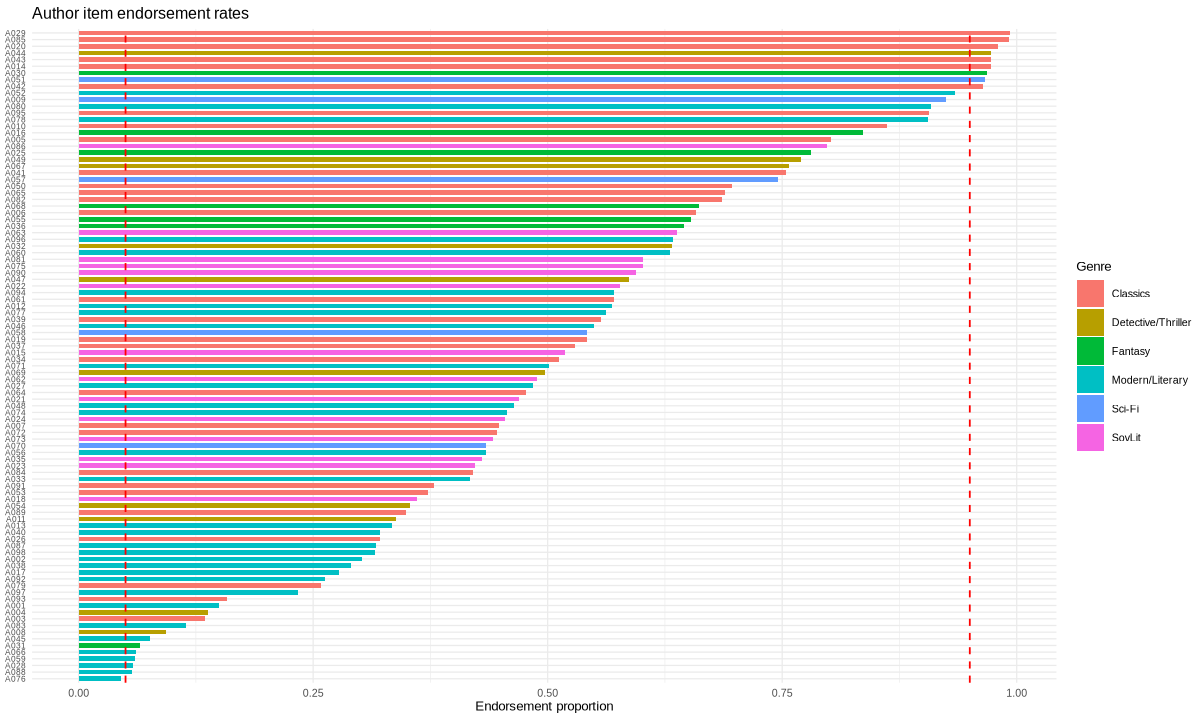

In [3]:
endorsement <- colMeans(author_mat, na.rm = TRUE)

cat("── Item endorsement rate summary ──\n")
cat(sprintf("  Mean:   %.3f\n", mean(endorsement)))
cat(sprintf("  Median: %.3f\n", median(endorsement)))
cat(sprintf("  Min:    %.3f  (%s)\n", min(endorsement), names(which.min(endorsement))))
cat(sprintf("  Max:    %.3f  (%s)\n", max(endorsement), names(which.max(endorsement))))
cat(sprintf("  Items < .05: %d\n", sum(endorsement < 0.05)))
cat(sprintf("  Items > .95: %d\n", sum(endorsement > 0.95)))

endorse_df <- data.frame(
  item = names(endorsement),
  rate = as.numeric(endorsement),
  stringsAsFactors = FALSE
)
endorse_df <- merge(endorse_df, item_key[, c("matrix_item_id", "item_label", "genre")],
                    by.x = "item", by.y = "matrix_item_id", all.x = TRUE)
endorse_df <- endorse_df[order(endorse_df$rate), ]

options(repr.plot.width = 10, repr.plot.height = 6)
ggplot(endorse_df, aes(x = reorder(item, rate), y = rate, fill = genre)) +
  geom_col(width = 0.7) +
  geom_hline(yintercept = c(0.05, 0.95), linetype = "dashed", color = "red", linewidth = 0.5) +
  coord_flip() +
  labs(title = "Author item endorsement rates",
       x = NULL, y = "Endorsement proportion", fill = "Genre") +
  theme_minimal(base_size = 8) +
  theme(axis.text.y = element_text(size = 5))

In [4]:
cat("Computing tetrachoric correlations (this may take a minute for 98 items)...\n")
tet <- psych::tetrachoric(author_mat)

cat("\n── Tetrachoric correlation matrix summary ──\n")
cat(sprintf("  Dimensions: %d × %d\n", nrow(tet$rho), ncol(tet$rho)))

off_diag <- tet$rho[lower.tri(tet$rho)]
cat(sprintf("  Off-diagonal correlations:\n"))
cat(sprintf("    Mean:   %.4f\n", mean(off_diag)))
cat(sprintf("    Median: %.4f\n", median(off_diag)))
cat(sprintf("    Min:    %.4f\n", min(off_diag)))
cat(sprintf("    Max:    %.4f\n", max(off_diag)))
cat(sprintf("    SD:     %.4f\n", sd(off_diag)))

# Check positive-definiteness
eig_vals_raw <- eigen(tet$rho, only.values = TRUE)$values
n_negative <- sum(eig_vals_raw < 0)
if (n_negative > 0) {
  cat(sprintf("\n  WARNING: Matrix is NOT positive definite (%d negative eigenvalues).\n", n_negative))
  cat("  Will use smoothed version where needed.\n")
} else {
  cat("\n  Matrix is positive definite.\n")
}

Computing tetrachoric correlations (this may take a minute for 98 items)...


For i = 9 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 9 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 2  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 4  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 7  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 13  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 18 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 4  A c



── Tetrachoric correlation matrix summary ──
  Dimensions: 98 × 98
  Off-diagonal correlations:
    Mean:   0.3872
    Median: 0.3991
    Min:    -0.2093
    Max:    0.7872
    SD:     0.1654

  Matrix is positive definite.


### Tetrachoric diagnostics (sparse 2×2 tables)

`psych::tetrachoric` applies a 0.5 continuity correction when any 2×2 cell count is zero (the messages you see during estimation). The next cell lists lowest-prevalence items, item pairs with at least one empty 2×2 cell, and items that appear most often in those pairs.


In [5]:
# After psych::tetrachoric: diagnose sparse 2x2 tables (zero cells → continuity correction 0.5)
# and rank low-prevalence items.

cat("── Tetrachoric / sparse 2×2 diagnostics ──\n\n")

# Build label lookup: matrix_item_id → "Author Name (A0xx)"
label_lookup <- setNames(
  paste0(item_key$item_label, " (", item_key$matrix_item_id, ")"),
  item_key$matrix_item_id
)

# 1) Rank items by prevalence (mean of binary 0/1)
item_prev <- colMeans(author_mat, na.rm = TRUE)
prev_tbl <- data.frame(
  item       = colnames(author_mat),
  author     = label_lookup[colnames(author_mat)],
  prevalence = as.numeric(item_prev),
  stringsAsFactors = FALSE
)
prev_tbl <- prev_tbl[order(prev_tbl$prevalence), ]
cat("Lowest-prevalence items (head 20):\n")
print(head(prev_tbl, 20), row.names = FALSE)

# 2) Item pairs with at least one zero cell in the 2x2 table
x <- as.matrix(author_mat)
p <- ncol(x)
pair_rows <- vector("list", p * (p - 1) / 2)
k <- 1L

for (i in 2:p) {
  xi <- x[, i]
  for (j in 1:(i - 1)) {
    xj <- x[, j]
    ok <- is.finite(xi) & is.finite(xj)
    if (!any(ok)) next

    tab <- table(
      factor(xi[ok], levels = c(0, 1)),
      factor(xj[ok], levels = c(0, 1))
    )

    zero_cells <- sum(tab == 0)
    if (zero_cells > 0) {
      pair_rows[[k]] <- data.frame(
        item_i  = colnames(x)[i],
        author_i = label_lookup[colnames(x)[i]],
        item_j  = colnames(x)[j],
        author_j = label_lookup[colnames(x)[j]],
        n00 = unname(tab["0", "0"]),
        n01 = unname(tab["0", "1"]),
        n10 = unname(tab["1", "0"]),
        n11 = unname(tab["1", "1"]),
        zero_cells = zero_cells,
        stringsAsFactors = FALSE
      )
      k <- k + 1L
    }
  }
}

problem_pairs <- do.call(rbind, pair_rows)
if (is.null(problem_pairs) || nrow(problem_pairs) == 0) {
  cat("\nNo pairs with zero 2x2 cells found.\n")
} else {
  problem_pairs <- problem_pairs[order(-problem_pairs$zero_cells), ]
  cat(sprintf("\nPairs with >=1 zero cell in 2x2 table (showing first 40 of %d):\n",
              nrow(problem_pairs)))
  print(head(problem_pairs, 40), row.names = FALSE)
  cat(sprintf("\nTotal problematic pairs: %d out of %d (%.2f%%)\n",
              nrow(problem_pairs), p * (p - 1) / 2,
              100 * nrow(problem_pairs) / (p * (p - 1) / 2)))
}

# 3) Items that appear most often in problematic pairs
if (!is.null(problem_pairs) && nrow(problem_pairs) > 0) {
  all_items_in_pairs <- c(problem_pairs$item_i, problem_pairs$item_j)
  item_counts <- table(all_items_in_pairs)
  item_problem_tbl <- data.frame(
    item            = names(item_counts),
    author          = label_lookup[names(item_counts)],
    n_problem_pairs = as.integer(item_counts),
    stringsAsFactors = FALSE
  )
  item_problem_tbl <- item_problem_tbl[order(-item_problem_tbl$n_problem_pairs), ]
  cat("\nItems appearing most often in problematic pairs (top 20):\n")
  print(head(item_problem_tbl, 20), row.names = FALSE)
}


── Tetrachoric / sparse 2×2 diagnostics ──

Lowest-prevalence items (head 20):
 item                       author prevalence
 A076       Yustein Gordier (A076) 0.04505814
 A088 Reshad Nuri Gyuntekin (A088) 0.05668605
 A028    Marie - Aude Murai (A028) 0.05813953
 A059     Catherine Stokett (A059) 0.05959302
 A066 Gregory David Roberts (A066) 0.06104651
 A031           Lee Bardugo (A031) 0.06540698
 A045        Art Spiegelman (A045) 0.07558140
 A008         Paula Hawkins (A008) 0.09302326
 A083       Frederik Bucman (A083) 0.11482558
 A003      Archibald Cronin (A003) 0.13517442
 A004         Gillian Flynn (A004) 0.13808140
 A001       Khaled Hosseini (A001) 0.14970930
 A093        Lawrense Stern (A093) 0.15843023
 A097      Mikhail Elizarov (A097) 0.23401163
 A079            Boris Vian (A079) 0.25872093
 A092          Markus Zusak (A092) 0.26308140
 A017       Narine Abgaryan (A017) 0.27761628
 A038         Alexey Ivanov (A038) 0.29069767
 A002           Donna Tartt (A002) 0.30232558
 

### Sparsity quantification

The next cell quantifies the overall sparsity burden: what fraction of all pairwise tetrachoric correlations required a continuity correction (due to a zero cell in the 2×2 table), which items contribute most, and a binary heatmap showing the spatial pattern of zero-cell pairs ordered by endorsement rate.

── Sparsity quantification ──

Total item pairs:       4753
Problematic pairs:      251  (5.28%)
Clean pairs:            4502  (94.72%)

Per-item problem-pair counts (items with >= 1):
 item                         author endorsement_pct n_problem_pairs
 A029      Arthur Conan Doyle (A029)            99.3              63
 A014         Charles Dickens (A014)            97.2              30
 A020             Jack London (A020)            98.0              25
 A051            Ray Bradbury (A051)            96.7              23
 A052         Haruki Murakami (A052)            93.5              17
 A030       John R.R. Tolkien (A030)            96.8              16
 A028      Marie - Aude Murai (A028)             5.8              15
 A076         Yustein Gordier (A076)             4.5              15
 A042     Eric Maria Remarque (A042)            96.4              14
 A093          Lawrense Stern (A093)            15.8              14
 A044         Agatha Christie (A044)            97.2    

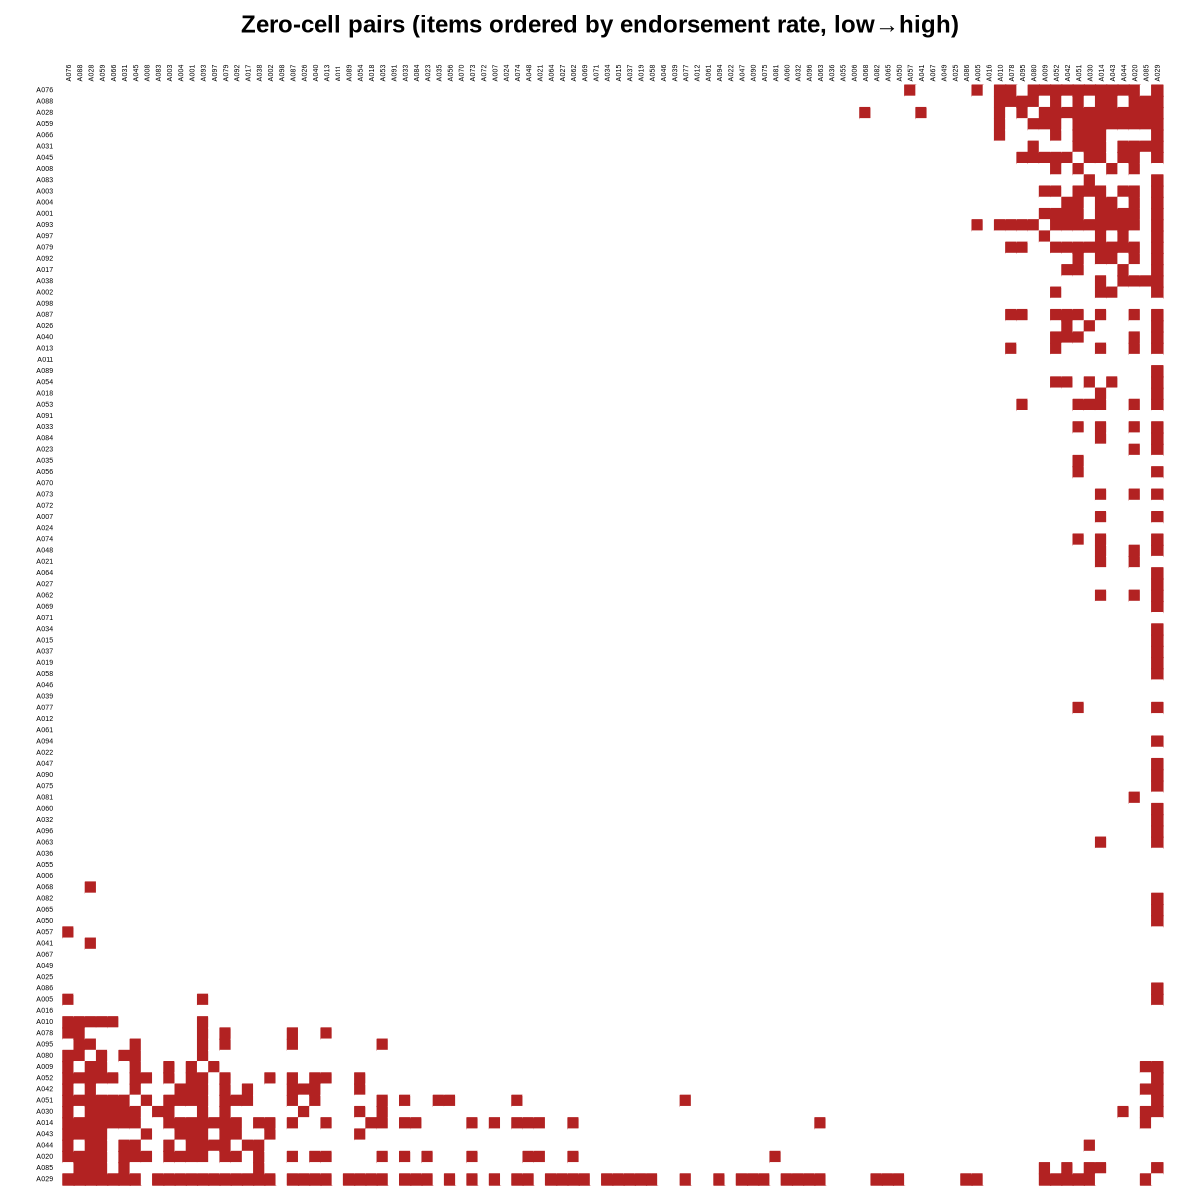

In [6]:
cat("── Sparsity quantification ──\n\n")

total_pairs <- ncol(author_mat) * (ncol(author_mat) - 1) / 2
n_prob      <- if (!is.null(problem_pairs)) nrow(problem_pairs) else 0L

cat(sprintf("Total item pairs:       %d\n", total_pairs))
cat(sprintf("Problematic pairs:      %d  (%.2f%%)\n", n_prob, 100 * n_prob / total_pairs))
cat(sprintf("Clean pairs:            %d  (%.2f%%)\n",
            total_pairs - n_prob, 100 * (total_pairs - n_prob) / total_pairs))

# Per-item problem-pair count (full ranking with author names and endorsement)
item_prev <- colMeans(author_mat, na.rm = TRUE)
all_items_in_pairs <- if (!is.null(problem_pairs)) c(problem_pairs$item_i, problem_pairs$item_j) else character(0)
item_counts_full <- table(factor(all_items_in_pairs, levels = colnames(author_mat)))

sparsity_tbl <- data.frame(
  item            = names(item_counts_full),
  author          = label_lookup[names(item_counts_full)],
  endorsement_pct = round(100 * item_prev[names(item_counts_full)], 1),
  n_problem_pairs = as.integer(item_counts_full),
  stringsAsFactors = FALSE
)
sparsity_tbl <- sparsity_tbl[order(-sparsity_tbl$n_problem_pairs), ]
cat("\nPer-item problem-pair counts (items with >= 1):\n")
print(sparsity_tbl[sparsity_tbl$n_problem_pairs > 0, ], row.names = FALSE)

# Binary sparsity heatmap: 1 = pair has a zero cell, ordered by endorsement rate
item_order <- names(sort(item_prev))
sparse_mat <- matrix(0L, nrow = ncol(author_mat), ncol = ncol(author_mat),
                     dimnames = list(colnames(author_mat), colnames(author_mat)))
if (!is.null(problem_pairs)) {
  for (r in seq_len(nrow(problem_pairs))) {
    sparse_mat[problem_pairs$item_i[r], problem_pairs$item_j[r]] <- 1L
    sparse_mat[problem_pairs$item_j[r], problem_pairs$item_i[r]] <- 1L
  }
}

options(repr.plot.width = 10, repr.plot.height = 10)
corrplot::corrplot(
  sparse_mat[item_order, item_order],
  method    = "color",
  col       = c("white", "firebrick"),
  is.corr   = FALSE,
  cl.pos    = "n",
  tl.cex    = 0.35,
  tl.col    = "black",
  title     = "Zero-cell pairs (items ordered by endorsement rate, low→high)",
  mar       = c(0, 0, 2, 0)
)

### Trimmed item set definition

**Rule:** exclude items with endorsement rate < 8% (too rare — many zero 2×2 cells) or > 95% (near-ceiling — many zero 2×2 cells). This captures the 10 items already flagged by `flag_endorsement_extreme_<.05_or_>.95` plus 4 near-boundary items (endorsement 5–8%) that the zero-cell diagnostics confirm as problematic.

The trimmed matrix will be used alongside the full matrix for all downstream dimensionality analyses, enabling a direct comparison of results with and without the sparsity-inducing items.

In [7]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  TRIMMED ITEM SET: DEFINITION & EXCLUSION REPORT\n")
cat("══════════════════════════════════════════════════════════════\n\n")

TRIM_LO <- 0.08
TRIM_HI <- 0.95

item_prev <- colMeans(author_mat, na.rm = TRUE)

# Build per-item problem-pair counts
all_items_pp <- if (!is.null(problem_pairs)) c(problem_pairs$item_i, problem_pairs$item_j) else character(0)
pp_counts    <- table(factor(all_items_pp, levels = colnames(author_mat)))

excl_mask <- (item_prev < TRIM_LO) | (item_prev > TRIM_HI)
excl_items <- colnames(author_mat)[excl_mask]
kept_items <- colnames(author_mat)[!excl_mask]

# Exclusion report table
excl_df <- data.frame(
  item            = excl_items,
  author          = label_lookup[excl_items],
  genre           = item_key$genre[match(excl_items, item_key$matrix_item_id)],
  endorsement_pct = round(100 * item_prev[excl_items], 1),
  n_problem_pairs = as.integer(pp_counts[excl_items]),
  cITC            = round(item_key$corrected_item_total_corr[
                      match(excl_items, item_key$matrix_item_id)], 4),
  reason          = ifelse(item_prev[excl_items] < TRIM_LO, "low (<8%)", "high (>95%)"),
  stringsAsFactors = FALSE
)
excl_df <- excl_df[order(excl_df$endorsement_pct), ]

cat(sprintf("Trimming rule: endorsement < %.0f%% or > %.0f%%\n", 100*TRIM_LO, 100*TRIM_HI))
cat(sprintf("Items excluded: %d  |  Items retained: %d\n\n", length(excl_items), length(kept_items)))

cat("── Excluded items ──\n")
print(excl_df, row.names = FALSE)

# Flag excluded items with high cITC (potential information loss)
high_citc_excl <- excl_df[excl_df$cITC > 0.30, ]
if (nrow(high_citc_excl) > 0) {
  cat(sprintf("\n  NOTE: %d excluded item(s) have cITC > 0.30 (potential information loss):\n",
              nrow(high_citc_excl)))
  for (r in seq_len(nrow(high_citc_excl))) {
    cat(sprintf("    %s — cITC = %.4f\n", high_citc_excl$author[r], high_citc_excl$cITC[r]))
  }
}

# Borderline items kept
borderline <- data.frame(
  item            = kept_items,
  author          = label_lookup[kept_items],
  endorsement_pct = round(100 * item_prev[kept_items], 1),
  stringsAsFactors = FALSE
)
borderline <- borderline[(borderline$endorsement_pct >= 8 & borderline$endorsement_pct < 10) |
                         (borderline$endorsement_pct > 90 & borderline$endorsement_pct <= 95), ]
borderline <- borderline[order(borderline$endorsement_pct), ]
if (nrow(borderline) > 0) {
  cat("\n── Borderline items (kept but noted) ──\n")
  print(borderline, row.names = FALSE)
}

# Create trimmed matrix
author_mat_trimmed <- author_mat[, kept_items]
cat(sprintf("\nauthor_mat_trimmed: %d participants × %d items\n",
            nrow(author_mat_trimmed), ncol(author_mat_trimmed)))

# Verify residual sparsity on trimmed matrix
xt <- as.matrix(author_mat_trimmed)
pt <- ncol(xt)
n_prob_trimmed <- 0L
residual_pairs <- list()
rk <- 1L

for (i in 2:pt) {
  xi <- xt[, i]
  for (j in 1:(i - 1)) {
    xj <- xt[, j]
    ok <- is.finite(xi) & is.finite(xj)
    if (!any(ok)) next
    tab <- table(factor(xi[ok], levels = c(0,1)), factor(xj[ok], levels = c(0,1)))
    if (any(tab == 0)) {
      n_prob_trimmed <- n_prob_trimmed + 1L
      residual_pairs[[rk]] <- data.frame(
        item_i   = colnames(xt)[i],
        author_i = label_lookup[colnames(xt)[i]],
        item_j   = colnames(xt)[j],
        author_j = label_lookup[colnames(xt)[j]],
        stringsAsFactors = FALSE
      )
      rk <- rk + 1L
    }
  }
}

total_trimmed_pairs <- pt * (pt - 1) / 2
cat(sprintf("\n── Residual sparsity after trimming ──\n"))
cat(sprintf("  Total pairs:      %d\n", total_trimmed_pairs))
cat(sprintf("  Problem pairs:    %d  (%.2f%%)\n",
            n_prob_trimmed, 100 * n_prob_trimmed / total_trimmed_pairs))
cat(sprintf("  Reduction:        %d → %d  (%.0f%% fewer)\n",
            n_prob, n_prob_trimmed,
            100 * (1 - n_prob_trimmed / max(n_prob, 1))))

if (length(residual_pairs) > 0) {
  residual_df <- do.call(rbind, residual_pairs)
  cat("\n  Remaining zero-cell pairs:\n")
  print(residual_df, row.names = FALSE)
}

══════════════════════════════════════════════════════════════
  TRIMMED ITEM SET: DEFINITION & EXCLUSION REPORT
══════════════════════════════════════════════════════════════

Trimming rule: endorsement < 8% or > 95%
Items excluded: 16  |  Items retained: 82

── Excluded items ──
 item                       author              genre endorsement_pct
 A076       Yustein Gordier (A076)    Modern/Literary             4.5
 A088 Reshad Nuri Gyuntekin (A088)    Modern/Literary             5.7
 A028    Marie - Aude Murai (A028)    Modern/Literary             5.8
 A059     Catherine Stokett (A059)    Modern/Literary             6.0
 A066 Gregory David Roberts (A066)    Modern/Literary             6.1
 A031           Lee Bardugo (A031)            Fantasy             6.5
 A045        Art Spiegelman (A045)    Modern/Literary             7.6
 A042   Eric Maria Remarque (A042)           Classics            96.4
 A051          Ray Bradbury (A051)             Sci-Fi            96.7
 A030     John R.R

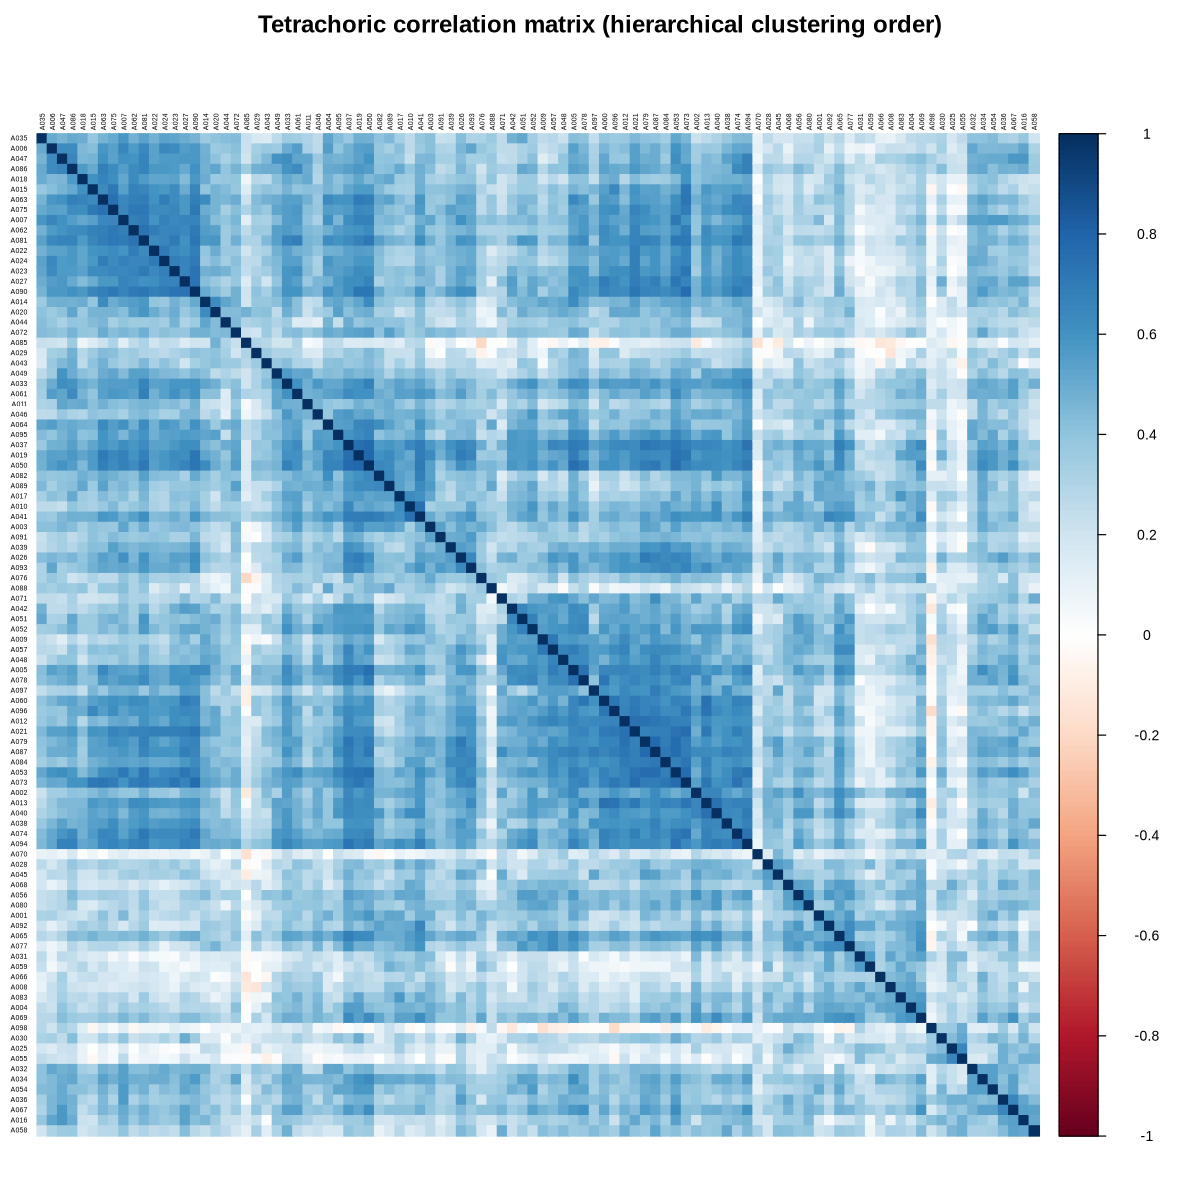

In [8]:
options(repr.plot.width = 10, repr.plot.height = 10)
corrplot::corrplot(
  tet$rho,
  method    = "color",
  order     = "hclust",
  hclust.method = "ward.D2",
  tl.cex    = 0.35,
  tl.col    = "black",
  cl.cex    = 0.7,
  title     = "Tetrachoric correlation matrix (hierarchical clustering order)",
  mar       = c(0, 0, 2, 0)
)

In [9]:
eig_vals <- eigen(tet$rho)$values

cat("── First 15 eigenvalues of tetrachoric correlation matrix ──\n")
eig_table <- data.frame(
  Factor      = 1:15,
  Eigenvalue  = round(eig_vals[1:15], 4),
  Prop_Var    = round(eig_vals[1:15] / sum(eig_vals[eig_vals > 0]), 4),
  Cum_Var     = round(cumsum(eig_vals[1:15]) / sum(eig_vals[eig_vals > 0]), 4)
)
print(eig_table, row.names = FALSE)

cat(sprintf("\nRatio eigenvalue1 / eigenvalue2: %.2f\n", eig_vals[1] / eig_vals[2]))
cat(sprintf("Eigenvalue 1: %.4f  (%.1f%% of variance)\n",
    eig_vals[1], 100 * eig_vals[1] / sum(eig_vals[eig_vals > 0])))

── First 15 eigenvalues of tetrachoric correlation matrix ──
 Factor Eigenvalue Prop_Var Cum_Var
      1    40.6964   0.4153  0.4153
      2     6.3878   0.0652  0.4805
      3     4.5471   0.0464  0.5268
      4     3.9162   0.0400  0.5668
      5     3.0453   0.0311  0.5979
      6     2.2251   0.0227  0.6206
      7     1.9005   0.0194  0.6400
      8     1.8278   0.0187  0.6586
      9     1.6421   0.0168  0.6754
     10     1.5318   0.0156  0.6910
     11     1.3974   0.0143  0.7053
     12     1.3815   0.0141  0.7194
     13     1.3738   0.0140  0.7334
     14     1.3173   0.0134  0.7468
     15     1.1517   0.0118  0.7586

Ratio eigenvalue1 / eigenvalue2: 6.37
Eigenvalue 1: 40.6964  (41.5% of variance)


── Parallel analysis (tetrachoric, via psych::fa.parallel) ──



For i = 9 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 9 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 2  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 4  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 7  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 13  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 18 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 4  A c

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

For i = 16 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 28 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 28 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 8  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 9  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 10  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 15  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

For i = 28 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 2  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 9  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 10  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 12  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 16  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 25  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 27  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 30 j = 9  A cell entry of 0 w

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

For i = 20 j = 4  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 6  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 8  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 9  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 10  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 22 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 28 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 5  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 8  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 9  A cell entry of 0 was 

...

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

For i = 14 j = 9  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 9  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 4  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 8  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 9  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 30 j = 9  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 30 j = 29  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 31 j = 29  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 42 j = 8  A cell entry of 0 was 

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

For i = 20 j = 8  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 8  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 9  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 13  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 16  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 18  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 22  A cell entry of 0 w

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

For i = 14 j = 4  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 4  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 9  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 10  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 21  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 30 j = 14  A cell entry of 0 wa

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0



Parallel analysis suggests that the number of factors =  16  and the number of components =  NA 

Parallel analysis: 16 factor(s) with eigenvalues above 95th percentile of random data.

Actual vs simulated 95th-percentile eigenvalues (first 15):
 Factor  Actual Simulated_95 Above_Random
      1 40.1773       0.8589          ***
      2  5.7200       0.7995          ***
      3  3.9233       0.7595          ***
      4  3.1889       0.7250          ***
      5  2.3943       0.6897          ***
      6  1.6019       0.6658          ***
      7  1.2677       0.6392          ***
      8  1.1918       0.6131          ***
      9  1.0087       0.5886          ***
     10  0.8725       0.5636          ***
     11  0.7726       0.5427          ***
     12  0.7533       0.5210          ***
     13  0.7233       0.5001          ***
     14  0.6401       0.4826          ***
     15  0.5167       0.4629          ***


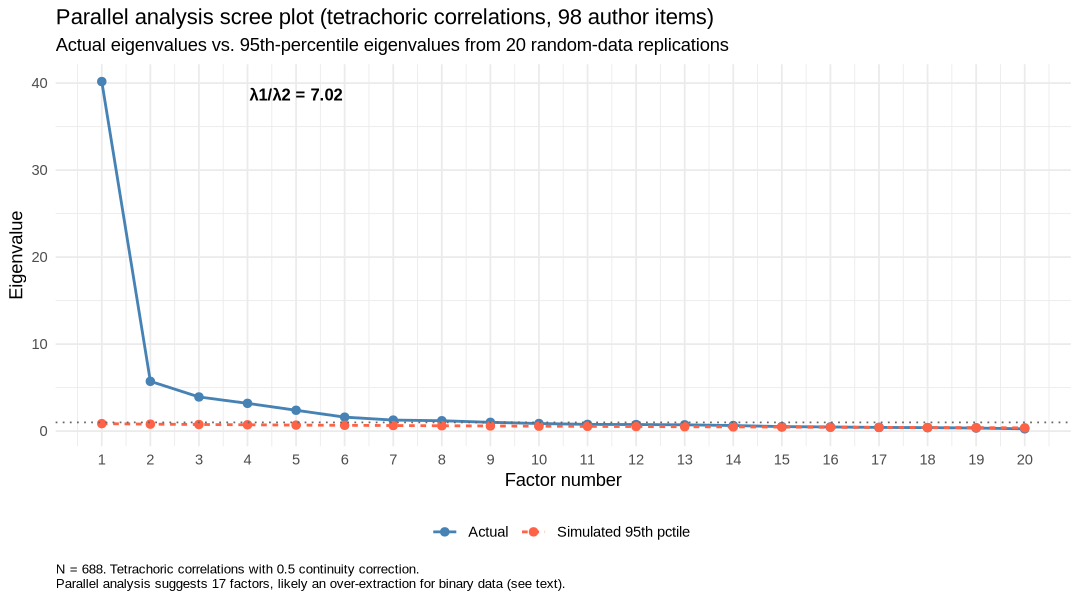

In [10]:
cat("── Parallel analysis (tetrachoric, via psych::fa.parallel) ──\n\n")

# mc.cores = 1 is set globally in cell 1, so fa.parallel runs serially (no fork).
set.seed(42)
pa <- psych::fa.parallel(author_mat, cor = "tet", fa = "fa", n.iter = 20,
                         plot = FALSE, correct = 0.5)

pa_nfact <- pa$nfact
cat(sprintf("\nParallel analysis: %d factor(s) with eigenvalues above 95th percentile of random data.\n", pa_nfact))

cat("\nActual vs simulated 95th-percentile eigenvalues (first 15):\n")
comp_df <- data.frame(
  Factor        = 1:15,
  Actual        = round(pa$fa.values[1:15], 4),
  Simulated_95  = round(pa$fa.sim[1:15], 4),
  Above_Random  = ifelse(pa$fa.values[1:15] > pa$fa.sim[1:15], "***", "")
)
print(comp_df, row.names = FALSE)

# Scree plot with parallel analysis overlay
options(repr.plot.width = 9, repr.plot.height = 5)
n_show <- min(20, length(pa$fa.values))
pa_plot_df <- data.frame(
  Factor = rep(1:n_show, 2),
  Eigenvalue = c(pa$fa.values[1:n_show], pa$fa.sim[1:n_show]),
  Source = rep(c("Actual", "Simulated 95th pctile"), each = n_show)
)

ggplot(pa_plot_df, aes(x = Factor, y = Eigenvalue, color = Source, linetype = Source)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 2) +
  geom_hline(yintercept = 1.0, linetype = "dotted", color = "grey40") +
  annotate("text", x = 5, y = pa$fa.values[1] - 1.5,
           label = sprintf("EV1/EV2 = %.2f", pa$fa.values[1] / pa$fa.values[2]),
           size = 3.5, fontface = "bold") +
  scale_x_continuous(breaks = 1:n_show) +
  scale_color_manual(values = c("Actual" = "steelblue", "Simulated 95th pctile" = "tomato")) +
  labs(title = "Parallel analysis scree plot (tetrachoric correlations, 98 author items)",
       subtitle = "Actual eigenvalues vs. 95th-percentile eigenvalues from 20 random-data replications",
       x = "Factor number", y = "Eigenvalue",
       caption = sprintf("N = %d. Tetrachoric correlations with 0.5 continuity correction.\nParallel analysis suggests %d factors; for binary items this often over-extracts (see text).", nrow(author_mat), pa_nfact)) +
  theme_minimal(base_size = 11) +
  theme(legend.position = "bottom",
        legend.title = element_blank(),
        plot.caption = element_text(size = 8, hjust = 0))

In [11]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  ONE-FACTOR EFA (tetrachoric, minres)\n")
cat("══════════════════════════════════════════════════════════════\n\n")

fa1 <- psych::fa(tet$rho, nfactors = 1, n.obs = nrow(author_mat), fm = "minres")
print(fa1)

# Loadings table with item metadata
load1 <- data.frame(
  item    = rownames(fa1$loadings),
  loading = as.numeric(fa1$loadings[, 1]),
  communality = fa1$communalities,
  uniqueness  = fa1$uniquenesses,
  stringsAsFactors = FALSE
)
load1 <- merge(load1, item_key[, c("matrix_item_id", "item_label", "genre",
               "selection_rate_pct", "corrected_item_total_corr")],
               by.x = "item", by.y = "matrix_item_id", all.x = TRUE)
load1 <- load1[order(load1$loading), ]

cat("\n── Items with lowest loadings (< 0.30) ──\n")
low_load <- load1[load1$loading < 0.30, ]
if (nrow(low_load) > 0) {
  print(low_load[, c("item", "item_label", "genre", "loading", "selection_rate_pct")],
        row.names = FALSE)
} else {
  cat("  None — all loadings >= 0.30\n")
}

cat(sprintf("\nProportion variance explained (1 factor): %.4f\n", fa1$Vaccounted[2, 1]))
cat(sprintf("RMSR: %.4f\n", fa1$rms))

══════════════════════════════════════════════════════════════
  ONE-FACTOR EFA (tetrachoric, minres)
══════════════════════════════════════════════════════════════



In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0



Factor Analysis using method =  minres
Call: psych::fa(r = tet$rho, nfactors = 1, n.obs = nrow(author_mat), 
    fm = "minres")
Standardized loadings (pattern matrix) based upon correlation matrix
      MR1    h2   u2 com
A001 0.54 0.286 0.71   1
A002 0.71 0.503 0.50   1
A003 0.63 0.401 0.60   1
A004 0.55 0.306 0.69   1
A005 0.82 0.673 0.33   1
A006 0.62 0.390 0.61   1
A007 0.75 0.562 0.44   1
A008 0.40 0.164 0.84   1
A009 0.61 0.367 0.63   1
A010 0.64 0.412 0.59   1
A011 0.56 0.316 0.68   1
A012 0.74 0.542 0.46   1
A013 0.76 0.571 0.43   1
A014 0.64 0.409 0.59   1
A015 0.66 0.429 0.57   1
A016 0.52 0.269 0.73   1
A017 0.63 0.401 0.60   1
A018 0.60 0.355 0.64   1
A019 0.85 0.719 0.28   1
A020 0.58 0.333 0.67   1
A021 0.76 0.584 0.42   1
A022 0.68 0.468 0.53   1
A023 0.72 0.521 0.48   1
A024 0.69 0.471 0.53   1
A025 0.29 0.082 0.92   1
A026 0.73 0.537 0.46   1
A027 0.74 0.554 0.45   1
A028 0.50 0.253 0.75   1
A029 0.42 0.173 0.83   1
A030 0.44 0.197 0.80   1
A031 0.34 0.117 0.88   1
A03

In [12]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  TWO-FACTOR EFA (tetrachoric, minres, oblimin rotation)\n")
cat("══════════════════════════════════════════════════════════════\n\n")

fa2 <- psych::fa(tet$rho, nfactors = 2, n.obs = nrow(author_mat),
                 fm = "minres", rotate = "oblimin")
print(fa2)

load2 <- data.frame(
  item = rownames(fa2$loadings),
  F1   = as.numeric(fa2$loadings[, 1]),
  F2   = as.numeric(fa2$loadings[, 2]),
  stringsAsFactors = FALSE
)
load2 <- merge(load2, item_key[, c("matrix_item_id", "item_label", "genre", "selection_rate_pct")],
               by.x = "item", by.y = "matrix_item_id", all.x = TRUE)

cat("\n── Factor correlation ──\n")
print(round(fa2$Phi, 4))

cat("\n── Items loading primarily on Factor 2 (|F2| > |F1|) ──\n")
f2_primary <- load2[abs(load2$F2) > abs(load2$F1), ]
f2_primary <- f2_primary[order(-abs(f2_primary$F2)), ]
if (nrow(f2_primary) > 0) {
  print(f2_primary[, c("item", "item_label", "genre", "F1", "F2", "selection_rate_pct")],
        row.names = FALSE)
} else {
  cat("  None — all items load primarily on Factor 1\n")
}

cat(sprintf("\nCumulative variance (2 factors): %.4f\n",
    sum(fa2$Vaccounted[2, ])))

══════════════════════════════════════════════════════════════
  TWO-FACTOR EFA (tetrachoric, minres, oblimin rotation)
══════════════════════════════════════════════════════════════



In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0



Factor Analysis using method =  minres
Call: psych::fa(r = tet$rho, nfactors = 2, n.obs = nrow(author_mat), 
    rotate = "oblimin", fm = "minres")
Standardized loadings (pattern matrix) based upon correlation matrix
       MR1   MR2    h2   u2 com
A001  0.12  0.58 0.420 0.58 1.1
A002  0.34  0.53 0.578 0.42 1.7
A003  0.34  0.43 0.443 0.56 1.9
A004  0.07  0.67 0.504 0.50 1.0
A005  0.65  0.27 0.672 0.33 1.3
A006  0.73 -0.10 0.463 0.54 1.0
A007  0.79 -0.01 0.611 0.39 1.0
A008 -0.08  0.68 0.405 0.59 1.0
A009  0.33  0.40 0.403 0.60 1.9
A010  0.31  0.47 0.471 0.53 1.7
A011  0.40  0.25 0.319 0.68 1.7
A012  0.69  0.10 0.555 0.44 1.0
A013  0.69  0.13 0.581 0.42 1.1
A014  0.62  0.06 0.426 0.57 1.0
A015  0.76 -0.10 0.507 0.49 1.0
A016  0.43  0.14 0.269 0.73 1.2
A017  0.27  0.52 0.484 0.52 1.5
A018  0.62  0.00 0.384 0.62 1.0
A019  0.69  0.26 0.718 0.28 1.3
A020  0.60  0.00 0.359 0.64 1.0
A021  0.91 -0.14 0.708 0.29 1.1
A022  0.82 -0.14 0.577 0.42 1.1
A023  0.90 -0.20 0.675 0.33 1.1
A024  0.89 -0.2

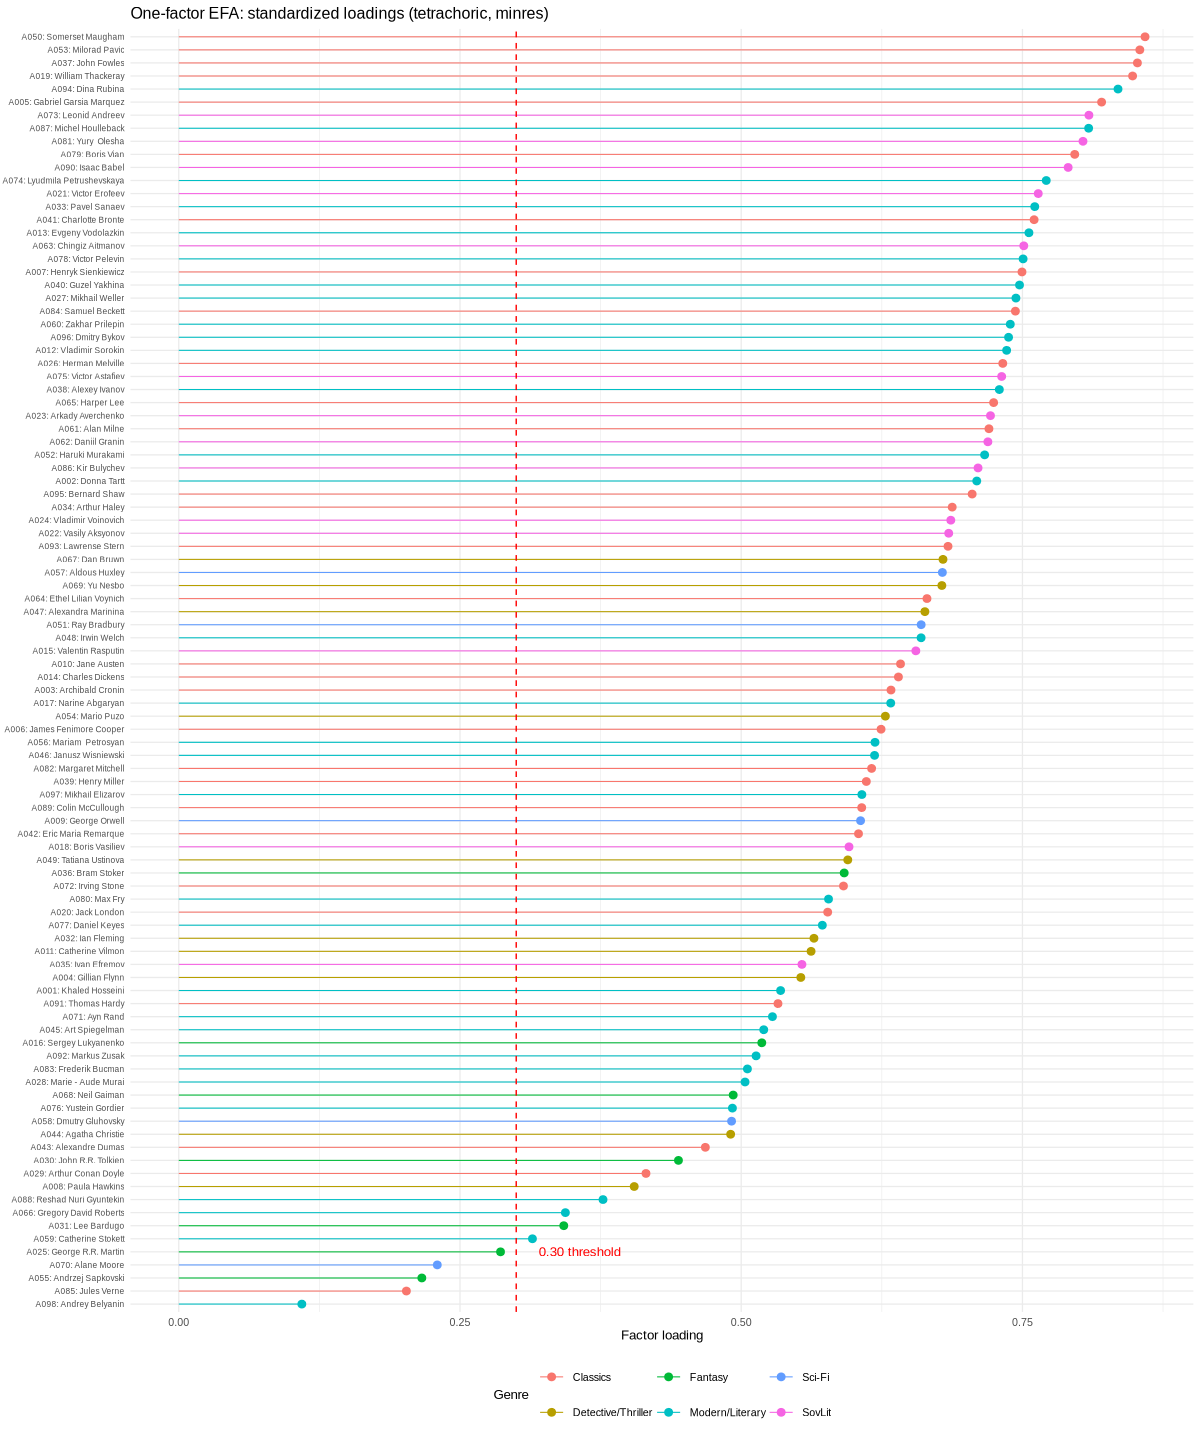

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 12)

load1_sorted <- load1[order(load1$loading), ]
load1_sorted$item_label_short <- ifelse(
  nchar(load1_sorted$item_label) > 25,
  paste0(substr(load1_sorted$item_label, 1, 22), "..."),
  load1_sorted$item_label
)
load1_sorted$display <- paste0(load1_sorted$item, ": ", load1_sorted$item_label_short)
load1_sorted$display <- factor(load1_sorted$display,
                               levels = load1_sorted$display)

ggplot(load1_sorted, aes(x = loading, y = display, color = genre)) +
  geom_point(size = 2) +
  geom_segment(aes(xend = 0, yend = display), linewidth = 0.3) +
  geom_vline(xintercept = 0.30, linetype = "dashed", color = "red", linewidth = 0.4) +
  annotate("text", x = 0.32, y = 5, label = "0.30 threshold",
           size = 2.8, color = "red", hjust = 0) +
  labs(title = "One-factor EFA: standardized loadings (tetrachoric, minres)",
       x = "Factor loading", y = NULL, color = "Genre") +
  theme_minimal(base_size = 8) +
  theme(axis.text.y = element_text(size = 5),
        legend.position = "bottom")

In [14]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  EXPLORATORY IFA WITH mirt (unidimensional 2PL)\n")
cat("══════════════════════════════════════════════════════════════\n\n")

cat("Fitting unidimensional 2PL model (EM algorithm)...\n")
mod1 <- mirt::mirt(author_mat, model = 1, itemtype = "2PL", verbose = FALSE)

cat("\n── Model summary ──\n")
print(mod1)

cat("\n── Item parameters (slope a1, intercept d) ──\n")
item_pars <- coef(mod1, IRTpars = TRUE, simplify = TRUE)$items
item_pars_df <- as.data.frame(item_pars)
item_pars_df$item <- rownames(item_pars_df)
item_pars_df <- merge(item_pars_df,
                      item_key[, c("matrix_item_id", "item_label", "genre")],
                      by.x = "item", by.y = "matrix_item_id", all.x = TRUE)
item_pars_df <- item_pars_df[order(item_pars_df$a), ]
print(item_pars_df, row.names = FALSE)

cat("\n── Items with near-zero discrimination (a < 0.30) ──\n")
low_disc <- item_pars_df[item_pars_df$a < 0.30, ]
if (nrow(low_disc) > 0) {
  print(low_disc[, c("item", "item_label", "genre", "a", "b")], row.names = FALSE)
} else {
  cat("  None — all items have a >= 0.30\n")
}

══════════════════════════════════════════════════════════════
  EXPLORATORY IFA WITH mirt (unidimensional 2PL)
══════════════════════════════════════════════════════════════

Fitting unidimensional 2PL model (EM algorithm)...

── Model summary ──

Call:
mirt::mirt(data = author_mat, model = 1, itemtype = "2PL", verbose = FALSE)

Full-information item factor analysis with 1 factor(s).
Converged within 1e-04 tolerance after 77 EM iterations.
mirt version: 1.46.1 
M-step optimizer: BFGS 
EM acceleration: Ramsay 
Number of rectangular quadrature: 61
Latent density type: Gaussian 

Log-likelihood = -27062.92
Estimated parameters: 196 
AIC = 54517.85
BIC = 55406.47; SABIC = 54784.14
G2 (1e+10) = 45135.35, p = 1
RMSEA = 0, CFI = NaN, TLI = NaN

── Item parameters (slope a1, intercept d) ──
 item         a            b g u              item_label              genre
 A098 0.1774324  4.398388512 0 1         Andrey Belyanin    Modern/Literary
 A055 0.3560875 -1.826927618 0 1       Andrzej Sapkov

In [15]:
cat("── M2 limited-information goodness-of-fit (may take a moment) ──\n\n")
m2_fit <- tryCatch(
  mirt::M2(mod1, type = "C2"),
  error = function(e) {
    cat("M2 computation failed:", conditionMessage(e), "\n")
    cat("Trying M2* (M2 with type='C2' fallback)...\n")
    tryCatch(mirt::M2(mod1), error = function(e2) {
      cat("M2 also failed:", conditionMessage(e2), "\n")
      NULL
    })
  }
)

if (!is.null(m2_fit)) {
  print(m2_fit)
} else {
  cat("M2 fit statistics could not be computed (common with large item sets).\n")
  cat("Proceeding with CFA-based fit assessment instead.\n")
}

── M2 limited-information goodness-of-fit (may take a moment) ──

            M2   df p RMSEA RMSEA_5 RMSEA_95 SRMSR   TLI   CFI
stats 17575.53 4655 0 0.064   0.063    0.065 0.059 0.935 0.936



── Discrimination (a) by genre ──
              genre mean_a median_a min_a max_a n_items
             SovLit   2.00     1.99  1.11  2.69      14
           Classics   2.05     1.94  0.49  3.50      30
             Sci-Fi   1.65     1.83  0.40  3.14       5
    Modern/Literary   1.67     1.48  0.18  3.40      32
 Detective/Thriller   1.36     1.37  0.93  1.69      10
            Fantasy   0.90     0.94  0.36  1.29       7

── Difficulty (b) summary ──
  Range: [-9.85, 4.40]
  Mean:  -0.09  |  Median: -0.08  |  SD: 1.85
  Items with |b| > 3 (extreme): 7


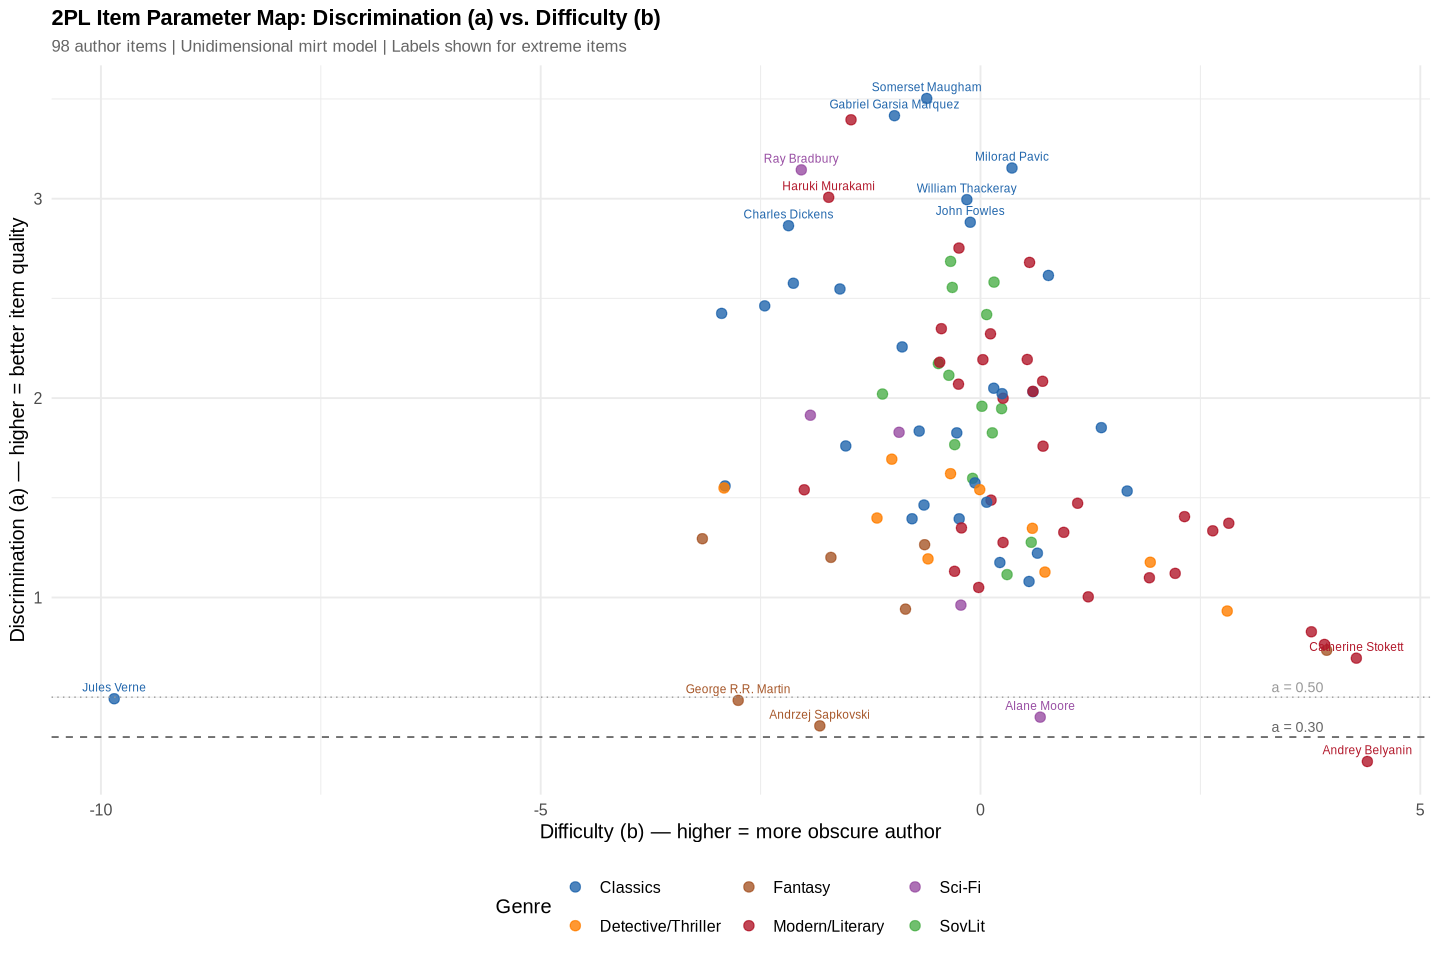

In [16]:
options(repr.plot.width = 12, repr.plot.height = 8)

ifa_df <- data.frame(
  item = rownames(item_pars_df),
  a    = item_pars_df$a,
  b    = item_pars_df$b,
  stringsAsFactors = FALSE
)
ifa_df$item <- item_pars_df$item
ifa_df <- merge(ifa_df,
                item_key[, c("matrix_item_id", "item_label", "genre", "selection_rate_pct")],
                by.x = "item", by.y = "matrix_item_id", all.x = TRUE)

genre_colors <- c(
  "Classics"           = "#2166AC",
  "Modern/Literary"    = "#B2182B",
  "SovLit"             = "#4DAF4A",
  "Detective/Thriller" = "#FF7F00",
  "Sci-Fi"             = "#984EA3",
  "Fantasy"            = "#A65628"
)

label_subset <- subset(ifa_df, a < 0.55 | a > 2.8 | abs(b) > 4)

use_repel <- requireNamespace("ggrepel", quietly = TRUE)

p <- ggplot(ifa_df, aes(x = b, y = a, color = genre)) +
  geom_point(size = 2.5, alpha = 0.8) +
  geom_hline(yintercept = 0.30, linetype = "dashed", color = "grey40", linewidth = 0.5) +
  geom_hline(yintercept = 0.50, linetype = "dotted", color = "grey60", linewidth = 0.4) +
  scale_color_manual(values = genre_colors) +
  annotate("text", x = max(ifa_df$b) - 0.5, y = 0.35,
           label = "a = 0.30", size = 3, color = "grey40", hjust = 1) +
  annotate("text", x = max(ifa_df$b) - 0.5, y = 0.55,
           label = "a = 0.50", size = 3, color = "grey60", hjust = 1) +
  labs(
    title = "2PL Item Parameter Map: Discrimination (a) vs. Difficulty (b)",
    subtitle = "98 author items | Unidimensional mirt model | Labels shown for extreme items",
    x = "Difficulty (b) — higher = more obscure author",
    y = "Discrimination (a) — higher = better item quality",
    color = "Genre"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "bottom",
    plot.title = element_text(face = "bold", size = 13),
    plot.subtitle = element_text(size = 10, color = "grey40")
  )

if (use_repel) {
  p <- p + ggrepel::geom_text_repel(
    data = label_subset,
    aes(label = item_label),
    size = 2.8, max.overlaps = 25, segment.alpha = 0.4,
    show.legend = FALSE
  )
} else {
  p <- p + geom_text(
    data = label_subset,
    aes(label = item_label),
    size = 2.5, check_overlap = TRUE, vjust = -0.8,
    show.legend = FALSE
  )
}

print(p)

cat("\n── Discrimination (a) by genre ──\n")
genre_agg <- do.call(rbind, lapply(split(ifa_df$a, ifa_df$genre), function(x) {
  data.frame(mean_a   = round(mean(x), 2),
             median_a = round(median(x), 2),
             min_a    = round(min(x), 2),
             max_a    = round(max(x), 2),
             n_items  = length(x))
}))
genre_agg$genre <- rownames(genre_agg)
genre_agg <- genre_agg[order(-genre_agg$median_a), c("genre", "mean_a", "median_a", "min_a", "max_a", "n_items")]
print(genre_agg, row.names = FALSE)

cat("\n── Difficulty (b) summary ──\n")
cat(sprintf("  Range: [%.2f, %.2f]\n", min(ifa_df$b), max(ifa_df$b)))
cat(sprintf("  Mean:  %.2f  |  Median: %.2f  |  SD: %.2f\n",
            mean(ifa_df$b), median(ifa_df$b), sd(ifa_df$b)))
cat(sprintf("  Items with |b| > 3 (extreme): %d\n", sum(abs(ifa_df$b) > 3)))

## 2. Confirmatory Unidimensionality Check

Following McCarron & Kuperman (2022), we fit a **one-factor CFA** treating all author items as
ordered/categorical indicators, using the **WLSMV** (weighted least squares, mean and variance
adjusted) estimator — the standard choice for binary/ordinal data in `lavaan`.

Reporting:
- RMSEA (+ 90% CI)
- CFI
- TLI
- SRMR (if available)
- Standardized factor loadings

In [17]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  ONE-FACTOR CFA (lavaan, WLSMV, categorical indicators)\n")
cat("══════════════════════════════════════════════════════════════\n\n")

author_cfa_df <- as.data.frame(author_mat)
item_names    <- colnames(author_cfa_df)

model_syntax <- paste0("F1 =~ ", paste(item_names, collapse = " + "))
cat("Model syntax (first 120 chars):", substr(model_syntax, 1, 120), "...\n\n")

cat("Fitting CFA (this may take several minutes with 98 binary items)...\n")
cfa_fit <- lavaan::cfa(
  model     = model_syntax,
  data      = author_cfa_df,
  ordered   = item_names,
  estimator = "WLSMV"
)

cat("\n── Full CFA summary ──\n\n")
summary(cfa_fit, fit.measures = TRUE, standardized = TRUE)

══════════════════════════════════════════════════════════════
  ONE-FACTOR CFA (lavaan, WLSMV, categorical indicators)
══════════════════════════════════════════════════════════════

Model syntax (first 120 chars): F1 =~ A001 + A002 + A003 + A004 + A005 + A006 + A007 + A008 + A009 + A010 + A011 + A012 + A013 + A014 + A015 + A016 + A0 ...

Fitting CFA (this may take several minutes with 98 binary items)...

── Full CFA summary ──



,lhs,op,rhs,exo,est,se,z,pvalue,std.lv,std.all
,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,F1,=~,A001,0,1.0000000,0.00000000,NA,NA,0.5502169,0.5502169
2,F1,=~,A002,0,1.3335825,0.11473637,11.623015,0.000000e+00,0.7337597,0.7337597
3,F1,=~,A003,0,1.1861189,0.11839352,10.018445,0.000000e+00,0.6526227,0.6526227
4,F1,=~,A004,0,1.0619165,0.10596503,10.021387,0.000000e+00,0.5842845,0.5842845
5,F1,=~,A005,0,1.5679291,0.13442119,11.664301,0.000000e+00,0.8627012,0.8627012
6,F1,=~,A006,0,1.2059082,0.11240918,10.727844,0.000000e+00,0.6635111,0.6635111
7,F1,=~,A007,0,1.4234183,0.11936004,11.925417,0.000000e+00,0.7831889,0.7831889
8,F1,=~,A008,0,0.7953558,0.12089406,6.578949,4.737877e-11,0.4376182,0.4376182
9,F1,=~,A009,0,1.2519375,0.13325081,9.395346,0.000000e+00,0.6888372,0.6888372


In [18]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  FIT INDICES SUMMARY\n")
cat("══════════════════════════════════════════════════════════════\n\n")

fm <- lavaan::fitMeasures(cfa_fit, c(
  "chisq", "df", "pvalue",
  "rmsea", "rmsea.ci.lower", "rmsea.ci.upper", "rmsea.pvalue",
  "cfi", "tli",
  "srmr"
))

fit_table <- data.frame(
  Index = c("Chi-square", "df", "p-value",
            "RMSEA", "RMSEA 90% CI lower", "RMSEA 90% CI upper", "RMSEA close-fit p",
            "CFI", "TLI",
            "SRMR"),
  Value = round(fm, 4),
  Threshold = c("", "", "",
                "< 0.08 acceptable, < 0.06 good", "", "", "> 0.05",
                "> 0.90 acceptable, > 0.95 good",
                "> 0.90 acceptable, > 0.95 good",
                "< 0.08 acceptable"),
  stringsAsFactors = FALSE
)
print(fit_table, row.names = FALSE)

cat("\n── Quick assessment ──\n")
cat(sprintf("  RMSEA = %.4f [%.4f, %.4f]  →  %s\n",
    fm["rmsea"], fm["rmsea.ci.lower"], fm["rmsea.ci.upper"],
    ifelse(fm["rmsea"] < 0.06, "GOOD", ifelse(fm["rmsea"] < 0.08, "ACCEPTABLE", "POOR"))))
cat(sprintf("  CFI   = %.4f  →  %s\n",
    fm["cfi"],
    ifelse(fm["cfi"] > 0.95, "GOOD", ifelse(fm["cfi"] > 0.90, "ACCEPTABLE", "POOR"))))
cat(sprintf("  TLI   = %.4f  →  %s\n",
    fm["tli"],
    ifelse(fm["tli"] > 0.95, "GOOD", ifelse(fm["tli"] > 0.90, "ACCEPTABLE", "POOR"))))
if (!is.na(fm["srmr"])) {
  cat(sprintf("  SRMR  = %.4f  →  %s\n",
      fm["srmr"],
      ifelse(fm["srmr"] < 0.08, "ACCEPTABLE", "POOR")))
}

══════════════════════════════════════════════════════════════
  FIT INDICES SUMMARY
══════════════════════════════════════════════════════════════

              Index      Value                      Threshold
         Chi-square 13873.5308                               
                 df  4655.0000                               
            p-value         NA                               
              RMSEA     0.0537 < 0.08 acceptable, < 0.06 good
 RMSEA 90% CI lower     0.0527                               
 RMSEA 90% CI upper     0.0547                               
  RMSEA close-fit p     0.0000                         > 0.05
                CFI     0.9729 > 0.90 acceptable, > 0.95 good
                TLI     0.9723 > 0.90 acceptable, > 0.95 good
               SRMR     0.1155              < 0.08 acceptable

── Quick assessment ──
  RMSEA = 0.0537 [0.0527, 0.0547]  →  GOOD
  CFI   = 0.9729  →  GOOD
  TLI   = 0.9723  →  GOOD
  SRMR  = 0.1155  →  POOR


In [19]:
cat("── Standardized factor loadings (CFA) ──\n\n")

std_est <- lavaan::standardizedSolution(cfa_fit)
loadings_df <- std_est[std_est$op == "=~", c("rhs", "est.std", "se", "z", "pvalue")]
names(loadings_df) <- c("item", "std_loading", "se", "z", "pvalue")

loadings_df <- merge(loadings_df,
                     item_key[, c("matrix_item_id", "item_label", "genre", "selection_rate_pct")],
                     by.x = "item", by.y = "matrix_item_id", all.x = TRUE)
loadings_df <- loadings_df[order(loadings_df$std_loading), ]

cat(sprintf("  Items total:     %d\n", nrow(loadings_df)))
cat(sprintf("  Loading >= 0.30: %d  (%.1f%%)\n",
    sum(loadings_df$std_loading >= 0.30),
    100 * sum(loadings_df$std_loading >= 0.30) / nrow(loadings_df)))
cat(sprintf("  Loading <  0.30: %d\n", sum(loadings_df$std_loading < 0.30)))
cat(sprintf("  Loading <  0.20: %d\n", sum(loadings_df$std_loading < 0.20)))
cat(sprintf("  Mean loading:    %.4f\n", mean(loadings_df$std_loading)))
cat(sprintf("  Median loading:  %.4f\n", median(loadings_df$std_loading)))

cat("\n── Full loadings table (sorted ascending) ──\n")
print(loadings_df[, c("item", "item_label", "genre", "std_loading", "se",
                      "selection_rate_pct")],
      row.names = FALSE)

── Standardized factor loadings (CFA) ──

  Items total:     98
  Loading >= 0.30: 93  (94.9%)
  Loading <  0.30: 5
  Loading <  0.20: 1
  Mean loading:    0.6585
  Median loading:  0.6882

── Full loadings table (sorted ascending) ──
 item              item_label              genre std_loading         se
 A098         Andrey Belyanin    Modern/Literary   0.1095984 0.05141982
 A070             Alane Moore             Sci-Fi   0.2330943 0.04648555
 A055       Andrzej Sapkovski            Fantasy   0.2335309 0.04534125
 A085             Jules Verne           Classics   0.2526052 0.12559566
 A025      George R.R. Martin            Fantasy   0.2910239 0.04904691
 A059       Catherine Stokett    Modern/Literary   0.3406847 0.06548506
 A031             Lee Bardugo            Fantasy   0.3725195 0.06244016
 A066   Gregory David Roberts    Modern/Literary   0.3741266 0.06837938
 A088   Reshad Nuri Gyuntekin    Modern/Literary   0.4115144 0.06410433
 A008           Paula Hawkins Detective/Thril

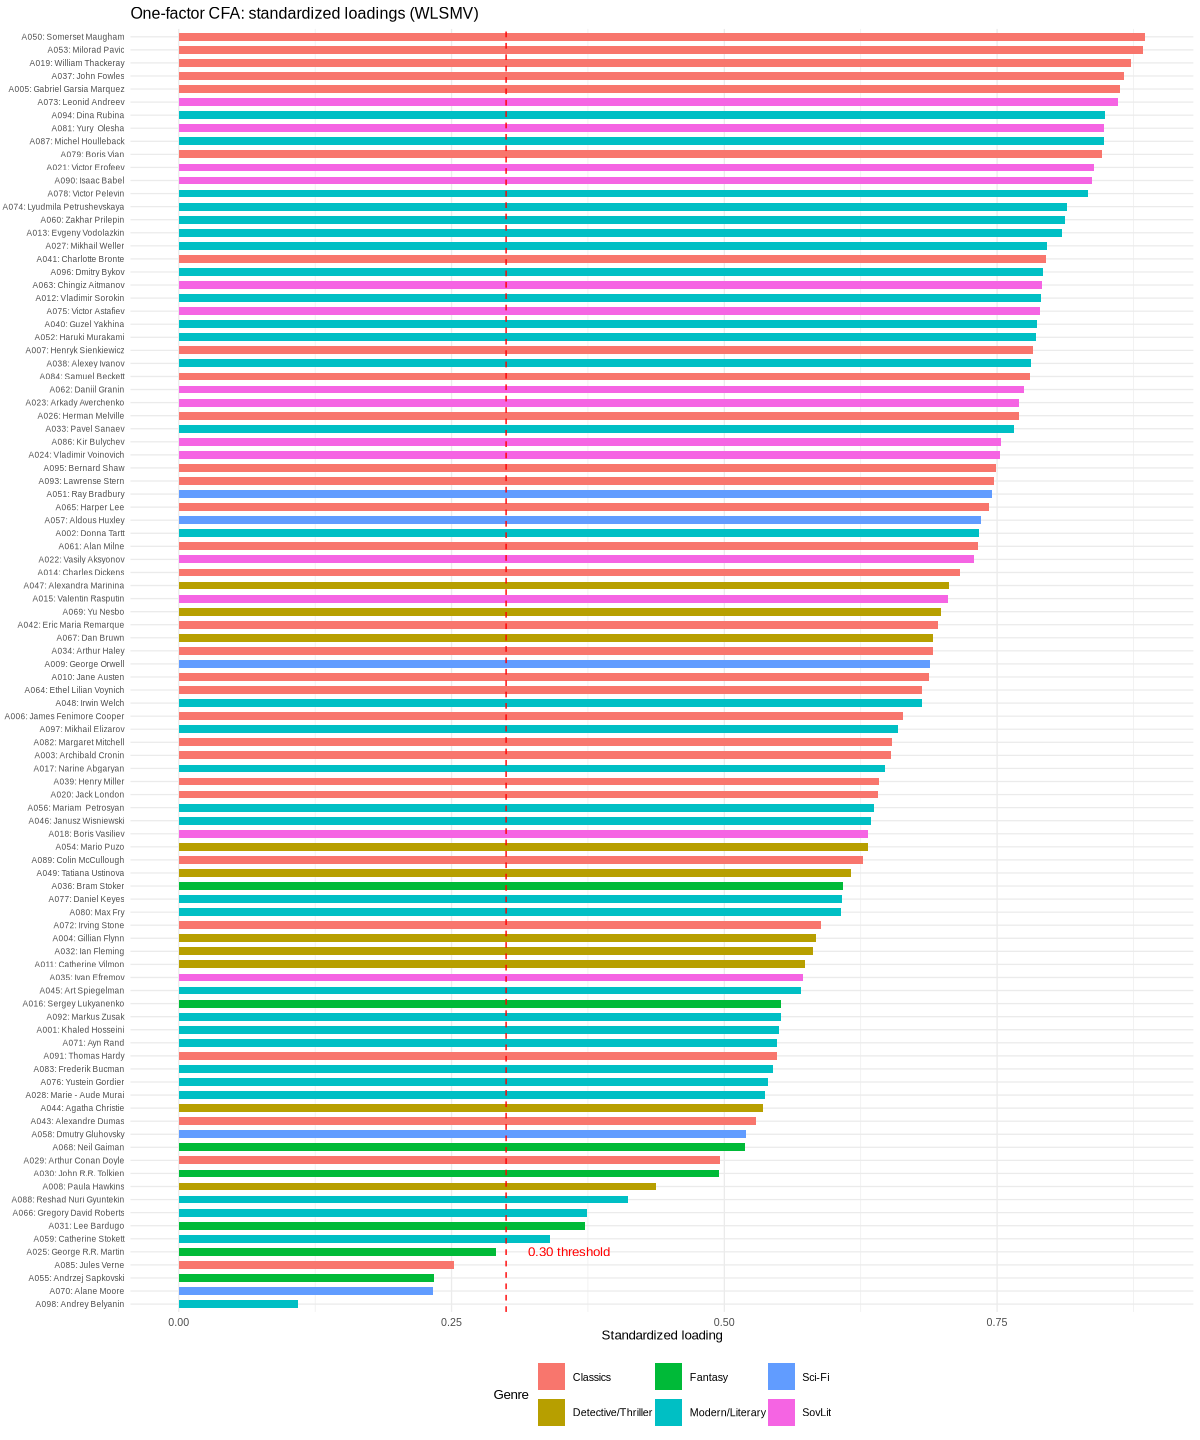

In [20]:
options(repr.plot.width = 10, repr.plot.height = 12)

loadings_df$item_label_short <- ifelse(
  nchar(loadings_df$item_label) > 25,
  paste0(substr(loadings_df$item_label, 1, 22), "..."),
  loadings_df$item_label
)
loadings_df$display <- paste0(loadings_df$item, ": ", loadings_df$item_label_short)
loadings_df$display <- factor(loadings_df$display, levels = loadings_df$display)

ggplot(loadings_df, aes(x = std_loading, y = display, fill = genre)) +
  geom_col(width = 0.6) +
  geom_vline(xintercept = 0.30, linetype = "dashed", color = "red", linewidth = 0.4) +
  annotate("text", x = 0.32, y = 5, label = "0.30 threshold",
           size = 2.8, color = "red", hjust = 0) +
  labs(title = "One-factor CFA: standardized loadings (WLSMV)",
       x = "Standardized loading", y = NULL, fill = "Genre") +
  theme_minimal(base_size = 8) +
  theme(axis.text.y = element_text(size = 5),
        legend.position = "bottom")

## 3. Foil Diagnostic (Secondary)

Foils are examined separately as a response-style diagnostic set. They should **not** be mixed
with author items in the main latent-trait model for print exposure.

In [21]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  FOIL RESPONSE-STYLE DIAGNOSTIC\n")
cat("══════════════════════════════════════════════════════════════\n\n")

foil_df <- read.csv(file.path(DATA_DIR,
  "ART_pretest_(for Castano)_EN__dimensionality_input__foil_response_matrix.csv"),
  stringsAsFactors = FALSE)
foil_mat <- as.matrix(foil_df[, -1])
foil_non_binary <- sum(!foil_mat %in% c(0, 1, NA))
if (foil_non_binary > 0) {
  cat(sprintf("  NOTE: %d foil cells had values outside {0,1} — dichotomizing.\n", foil_non_binary))
  foil_mat <- ifelse(foil_mat > 0, 1L, 0L)
  foil_mat <- matrix(foil_mat, nrow = nrow(foil_df),
                     dimnames = dimnames(as.matrix(foil_df[, -1])))
}
storage.mode(foil_mat) <- "integer"

cat(sprintf("Foil matrix: %d participants × %d items\n", nrow(foil_mat), ncol(foil_mat)))

foil_endorsement <- colMeans(foil_mat, na.rm = TRUE)
cat(sprintf("Mean foil endorsement: %.4f\n", mean(foil_endorsement)))
cat(sprintf("Max foil endorsement:  %.4f\n", max(foil_endorsement)))

# Remove zero-variance foils before tetrachoric
foil_var <- apply(foil_mat, 2, var, na.rm = TRUE)
foil_mat_clean <- foil_mat[, foil_var > 0]
cat(sprintf("Foils with non-zero variance: %d / %d\n", ncol(foil_mat_clean), ncol(foil_mat)))

cat("\nComputing foil tetrachoric correlations...\n")
foil_tet <- tryCatch(
  psych::tetrachoric(foil_mat_clean),
  error = function(e) {
    cat("Tetrachoric computation failed:", conditionMessage(e), "\n")
    NULL
  }
)

if (!is.null(foil_tet)) {
  foil_eig <- eigen(foil_tet$rho)$values
  cat("\nFirst 10 eigenvalues (foil tetrachoric):\n")
  print(round(foil_eig[1:min(10, length(foil_eig))], 4))
  cat(sprintf("Ratio eigenvalue1/eigenvalue2: %.2f\n", foil_eig[1] / foil_eig[2]))

  cat("\nNote: Foils are NOT included in the main latent-trait model.\n")
  cat("This analysis is for response-style diagnostics only.\n")
}

══════════════════════════════════════════════════════════════
  FOIL RESPONSE-STYLE DIAGNOSTIC
══════════════════════════════════════════════════════════════

Foil matrix: 688 participants × 104 items
Mean foil endorsement: 0.0150
Max foil endorsement:  0.1105
Foils with non-zero variance: 97 / 104

Computing foil tetrachoric correlations...


For i = 2 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 3 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 3 j = 2  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 4 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 4 j = 2  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 4 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 5 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 5 j = 2  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 5 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 5 j = 4  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 6 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 6 j = 3  A cell entry of



First 10 eigenvalues (foil tetrachoric):
 [1] 41.3967  2.8292  2.3225  2.2657  2.0617  1.9662  1.9190  1.8321  1.7472
[10]  1.6547
Ratio eigenvalue1/eigenvalue2: 14.63

Note: Foils are NOT included in the main latent-trait model.
This analysis is for response-style diagnostics only.


## 4. Decision & Summary

**Decision criteria** (following Moore & Gordon 2015; McCarron & Kuperman 2022):

Proceed with **unidimensional IRT** if:
1. The one-factor CFA fit is acceptable (RMSEA < 0.08, CFI > 0.90)
2. Most loadings are substantial (>= 0.30)
3. Any secondary factor mostly reflects extremely rare items or guessing-related items
4. The construct remains interpretable as *print exposure / author recognition*

Moore & Gordon saw evidence of a second factor but interpreted it as driven partly by rare items
and criterion-shift/guessing behavior, then continued with a cleaned unidimensional item set.

In [22]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  UNIDIMENSIONALITY DECISION SUMMARY\n")
cat("══════════════════════════════════════════════════════════════\n\n")

# Gather evidence
n_items <- nrow(loadings_df)
n_above_30 <- sum(loadings_df$std_loading >= 0.30)
n_below_20 <- sum(loadings_df$std_loading < 0.20)
pct_above_30 <- 100 * n_above_30 / n_items

rmsea_val <- fm["rmsea"]
cfi_val   <- fm["cfi"]
tli_val   <- fm["tli"]

eig_ratio <- eig_vals[1] / eig_vals[2]

pa_nfact <- pa$nfact

# Print summary
cat("── Evidence from exploratory analyses ──\n")
cat(sprintf("  Eigenvalue ratio (EV1/EV2):           %.2f\n", eig_ratio))
cat(sprintf("  Parallel analysis suggested factors: %d\n", pa_nfact))
cat(sprintf("  1-factor EFA variance explained:     %.1f%%\n",
    100 * fa1$Vaccounted[2, 1]))

cat("\n── Evidence from confirmatory CFA ──\n")
cat(sprintf("  RMSEA: %.4f  %s\n", rmsea_val,
    ifelse(rmsea_val < 0.06, "[GOOD]", ifelse(rmsea_val < 0.08, "[ACCEPTABLE]", "[POOR]"))))
cat(sprintf("  CFI:   %.4f  %s\n", cfi_val,
    ifelse(cfi_val > 0.95, "[GOOD]", ifelse(cfi_val > 0.90, "[ACCEPTABLE]", "[POOR]"))))
cat(sprintf("  TLI:   %.4f  %s\n", tli_val,
    ifelse(tli_val > 0.95, "[GOOD]", ifelse(tli_val > 0.90, "[ACCEPTABLE]", "[POOR]"))))

cat("\n── Loading quality ──\n")
cat(sprintf("  Items with loading >= 0.30: %d / %d  (%.1f%%)\n", n_above_30, n_items, pct_above_30))
cat(sprintf("  Items with loading <  0.20: %d\n", n_below_20))
cat(sprintf("  Mean loading:              %.4f\n", mean(loadings_df$std_loading)))

# Items on secondary factor
cat("\n── Secondary factor interpretation ──\n")
if (exists("f2_primary") && nrow(f2_primary) > 0) {
  cat(sprintf("  %d items loaded primarily on Factor 2 in the 2-factor EFA.\n", nrow(f2_primary)))
  f2_rates <- as.numeric(f2_primary$selection_rate_pct)
  cat(sprintf("  Their mean endorsement rate: %.1f%%\n", mean(f2_rates, na.rm = TRUE)))
  cat(sprintf("  Their endorsement range:     %.1f%% – %.1f%%\n",
      min(f2_rates, na.rm = TRUE), max(f2_rates, na.rm = TRUE)))
  cat("  Genre composition:\n")
  print(table(f2_primary$genre))
} else {
  cat("  No items loaded primarily on Factor 2.\n")
}

# Final recommendation
cat("\n══════════════════════════════════════════════════════════════\n")
cfa_acceptable <- (rmsea_val < 0.08) && (cfi_val > 0.90)
loadings_ok    <- pct_above_30 >= 80

if (cfa_acceptable && loadings_ok) {
  cat("  RECOMMENDATION: PROCEED with unidimensional IRT.\n")
  cat("  The one-factor model shows acceptable fit and the large\n")
  cat("  majority of items have substantial loadings.\n")
} else if (cfa_acceptable) {
  cat("  RECOMMENDATION: PROCEED with CAUTION.\n")
  cat("  CFA fit is acceptable, but a notable proportion of items\n")
  cat("  have weak loadings. Consider removing items < 0.20 before IRT.\n")
} else {
  cat("  RECOMMENDATION: INVESTIGATE FURTHER before proceeding.\n")
  cat("  CFA fit indices do not meet standard acceptability thresholds.\n")
  cat("  Consider item removal, bifactor models, or multidimensional IRT.\n")
}
cat("══════════════════════════════════════════════════════════════\n")

if (n_below_20 > 0) {
  cat("\n── Items flagged for potential removal (loading < 0.20) ──\n")
  flagged <- loadings_df[loadings_df$std_loading < 0.20,
                         c("item", "item_label", "genre", "std_loading", "selection_rate_pct")]
  print(flagged, row.names = FALSE)
}

cat(sprintf("\n  NOTE: See Section 5 below for a dual-track comparison (full %d items vs.\n", ncol(author_mat)))
cat(sprintf("  trimmed %d items per the endorsement rule above) to assess whether\n", ncol(author_mat_trimmed)))
cat("  sparse 2x2 tables distort these conclusions.\n")

══════════════════════════════════════════════════════════════
  UNIDIMENSIONALITY DECISION SUMMARY
══════════════════════════════════════════════════════════════

── Evidence from exploratory analyses ──
  Eigenvalue ratio (λ1/λ2):           6.37
  Parallel analysis suggested factors: 16
  1-factor EFA variance explained:     41.0%

── Evidence from confirmatory CFA ──
  RMSEA: 0.0537  [GOOD]
  CFI:   0.9729  [GOOD]
  TLI:   0.9723  [GOOD]

── Loading quality ──
  Items with loading >= 0.30: 93 / 98  (94.9%)
  Items with loading <  0.20: 1
  Mean loading:              0.6585

── Secondary factor interpretation ──
  33 items loaded primarily on Factor 2 in the 2-factor EFA.
  Their mean endorsement rate: 39.3%
  Their endorsement range:     4.5% – 92.4%
  Genre composition:

          Classics Detective/Thriller            Fantasy    Modern/Literary 
                 4                  4                  5                 17 
            Sci-Fi 
                 3 

═══════════════════

## 5. Dual-Track Dimensionality Comparison (Full vs. Trimmed)

This section re-runs the full dimensionality pipeline on the **trimmed author matrix** (items outside the 8–95% endorsement band excluded; see the trimming report in Section 1) and compares key metrics side-by-side with the full **98-item** results computed above.


In [23]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  TRIMMED MATRIX: TETRACHORIC CORRELATIONS & EIGENVALUES\n")
cat("══════════════════════════════════════════════════════════════\n\n")

cat(sprintf("Trimmed matrix: %d participants × %d items\n",
            nrow(author_mat_trimmed), ncol(author_mat_trimmed)))

cat("Computing tetrachoric correlations for trimmed matrix...\n")
tet_trimmed <- psych::tetrachoric(author_mat_trimmed)

cat("\n── Tetrachoric correlation matrix summary (trimmed) ──\n")
off_diag_tr <- tet_trimmed$rho[lower.tri(tet_trimmed$rho)]
cat(sprintf("  Off-diagonal correlations:\n"))
cat(sprintf("    Mean:   %.4f  (full: %.4f)\n", mean(off_diag_tr), mean(tet$rho[lower.tri(tet$rho)])))
cat(sprintf("    Median: %.4f\n", median(off_diag_tr)))
cat(sprintf("    Min:    %.4f\n", min(off_diag_tr)))
cat(sprintf("    Max:    %.4f\n", max(off_diag_tr)))
cat(sprintf("    SD:     %.4f\n", sd(off_diag_tr)))

eig_raw_tr <- eigen(tet_trimmed$rho, only.values = TRUE)$values
n_neg_tr <- sum(eig_raw_tr < 0)
if (n_neg_tr > 0) {
  cat(sprintf("\n  WARNING: Trimmed matrix NOT positive definite (%d negative eigenvalues).\n", n_neg_tr))
} else {
  cat("\n  Trimmed matrix is positive definite.\n")
}

eig_vals_trimmed <- eigen(tet_trimmed$rho)$values

cat("\n── First 15 eigenvalues (trimmed) ──\n")
eig_table_tr <- data.frame(
  Factor     = 1:15,
  Eigenvalue = round(eig_vals_trimmed[1:15], 4),
  Prop_Var   = round(eig_vals_trimmed[1:15] / sum(eig_vals_trimmed[eig_vals_trimmed > 0]), 4),
  Cum_Var    = round(cumsum(eig_vals_trimmed[1:15]) / sum(eig_vals_trimmed[eig_vals_trimmed > 0]), 4)
)
print(eig_table_tr, row.names = FALSE)

cat(sprintf("\nRatio EV1/EV2 (trimmed): %.2f  (full: %.2f)\n",
            eig_vals_trimmed[1] / eig_vals_trimmed[2],
            eig_vals[1] / eig_vals[2]))
cat(sprintf("Eigenvalue 1 (trimmed): %.4f  (%.1f%% of variance)\n",
            eig_vals_trimmed[1],
            100 * eig_vals_trimmed[1] / sum(eig_vals_trimmed[eig_vals_trimmed > 0])))

══════════════════════════════════════════════════════════════
  TRIMMED MATRIX: TETRACHORIC CORRELATIONS & EIGENVALUES
══════════════════════════════════════════════════════════════

Trimmed matrix: 688 participants × 82 items
Computing tetrachoric correlations for trimmed matrix...


For i = 9 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 9 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 41 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 41 j = 2  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 41 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 41 j = 8  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 41 j = 13  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 41 j = 34  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 43 j = 41  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 64 j = 13  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 65 j = 41  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 65 j = 64 



── Tetrachoric correlation matrix summary (trimmed) ──
  Off-diagonal correlations:
    Mean:   0.4394  (full: 0.3872)
    Median: 0.4523
    Min:    -0.1924
    Max:    0.8098
    SD:     0.1653

  Trimmed matrix is positive definite.

── First 15 eigenvalues (trimmed) ──
 Factor Eigenvalue Prop_Var Cum_Var
      1    38.1806   0.4656  0.4656
      2     5.5339   0.0675  0.5331
      3     4.0172   0.0490  0.5821
      4     3.7510   0.0457  0.6278
      5     2.0314   0.0248  0.6526
      6     1.8529   0.0226  0.6752
      7     1.5922   0.0194  0.6946
      8     1.3277   0.0162  0.7108
      9     1.2637   0.0154  0.7262
     10     1.0795   0.0132  0.7394
     11     1.0136   0.0124  0.7518
     12     0.9851   0.0120  0.7638
     13     0.9220   0.0112  0.7750
     14     0.9024   0.0110  0.7860
     15     0.8517   0.0104  0.7964

Ratio λ1/λ2 (trimmed): 6.90  (full: 6.37)
Eigenvalue 1 (trimmed): 38.1806  (46.6% of variance)


In [24]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  TRIMMED MATRIX: PARALLEL ANALYSIS & EFA\n")
cat("══════════════════════════════════════════════════════════════\n\n")

# Parallel analysis
set.seed(42)
pa_trimmed <- psych::fa.parallel(author_mat_trimmed, cor = "tet", fa = "fa",
                                  n.iter = 20, plot = FALSE, correct = 0.5)
pa_nfact_trimmed <- pa_trimmed$nfact
cat(sprintf("Parallel analysis (trimmed): %d factor(s) above 95th percentile\n",
            pa_nfact_trimmed))
cat(sprintf("  (full matrix: %d factor(s))\n\n", pa_nfact))

cat("Actual vs simulated eigenvalues (first 10, trimmed):\n")
comp_tr <- data.frame(
  Factor       = 1:10,
  Actual       = round(pa_trimmed$fa.values[1:10], 4),
  Simulated_95 = round(pa_trimmed$fa.sim[1:10], 4),
  Above_Random = ifelse(pa_trimmed$fa.values[1:10] > pa_trimmed$fa.sim[1:10], "***", "")
)
print(comp_tr, row.names = FALSE)

# One-factor EFA
cat("\n── One-factor EFA (trimmed, minres) ──\n")
fa1_trimmed <- psych::fa(tet_trimmed$rho, nfactors = 1, n.obs = nrow(author_mat_trimmed),
                          fm = "minres")

load1_tr <- data.frame(
  item    = rownames(fa1_trimmed$loadings),
  loading = as.numeric(fa1_trimmed$loadings[, 1]),
  stringsAsFactors = FALSE
)
load1_tr <- merge(load1_tr, item_key[, c("matrix_item_id", "item_label", "genre")],
                  by.x = "item", by.y = "matrix_item_id", all.x = TRUE)
load1_tr$author <- paste0(load1_tr$item_label, " (", load1_tr$item, ")")
load1_tr <- load1_tr[order(load1_tr$loading), ]

cat(sprintf("Proportion variance explained: %.4f  (full: %.4f)\n",
            fa1_trimmed$Vaccounted[2, 1], fa1$Vaccounted[2, 1]))
cat(sprintf("RMSR: %.4f  (full: %.4f)\n", fa1_trimmed$rms, fa1$rms))
cat(sprintf("Items with loading < 0.30: %d  (full: %d)\n",
            sum(load1_tr$loading < 0.30),
            sum(load1$loading < 0.30)))

low_load_tr <- load1_tr[load1_tr$loading < 0.30, ]
if (nrow(low_load_tr) > 0) {
  cat("\n  Low-loading items (trimmed, < 0.30):\n")
  print(low_load_tr[, c("author", "genre", "loading")], row.names = FALSE)
}

# Two-factor EFA
cat("\n── Two-factor EFA (trimmed, minres, oblimin) ──\n")
fa2_trimmed <- psych::fa(tet_trimmed$rho, nfactors = 2, n.obs = nrow(author_mat_trimmed),
                          fm = "minres", rotate = "oblimin")

load2_tr <- data.frame(
  item = rownames(fa2_trimmed$loadings),
  F1   = as.numeric(fa2_trimmed$loadings[, 1]),
  F2   = as.numeric(fa2_trimmed$loadings[, 2]),
  stringsAsFactors = FALSE
)
load2_tr <- merge(load2_tr, item_key[, c("matrix_item_id", "item_label", "genre",
                  "selection_rate_pct")],
                  by.x = "item", by.y = "matrix_item_id", all.x = TRUE)
load2_tr$author <- paste0(load2_tr$item_label, " (", load2_tr$item, ")")

cat("Factor correlation (trimmed):\n")
print(round(fa2_trimmed$Phi, 4))

f2_primary_tr <- load2_tr[abs(load2_tr$F2) > abs(load2_tr$F1), ]
f2_primary_tr <- f2_primary_tr[order(-abs(f2_primary_tr$F2)), ]
cat(sprintf("\nItems loading primarily on Factor 2: %d\n", nrow(f2_primary_tr)))
if (nrow(f2_primary_tr) > 0) {
  print(f2_primary_tr[, c("author", "genre", "F1", "F2", "selection_rate_pct")],
        row.names = FALSE)
}

cat(sprintf("\nCumulative variance (2 factors, trimmed): %.4f  (full: %.4f)\n",
            sum(fa2_trimmed$Vaccounted[2, ]), sum(fa2$Vaccounted[2, ])))

══════════════════════════════════════════════════════════════
  TRIMMED MATRIX: PARALLEL ANALYSIS & EFA
══════════════════════════════════════════════════════════════



For i = 9 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 9 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 41 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 41 j = 2  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 41 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 41 j = 8  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 41 j = 13  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 41 j = 34  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 43 j = 41  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 64 j = 13  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 65 j = 41  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 65 j = 64 

For i = 79 j = 64  A cell entry of 0 was replaced with correct =  0.5.  Check your data!



In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0



In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0



In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0



In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0



For i = 41 j = 9  A cell entry of 0 was replaced with correct =  0.5.  Check your data!



In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0




Parallel analysis suggests that the number of factors =  9  and the number of components =  NA 
Parallel analysis (trimmed): 9 factor(s) above 95th percentile
  (full matrix: 16 factor(s))

Actual vs simulated eigenvalues (first 10, trimmed):
 Factor  Actual Simulated_95 Above_Random
      1 37.7002       0.7783          ***
      2  4.9298       0.7113          ***
      3  3.4373       0.6669          ***
      4  3.0429       0.6343          ***
      5  1.4780       0.6067          ***
      6  1.3161       0.5776          ***
      7  0.9650       0.5548          ***
      8  0.7203       0.5288          ***
      9  0.6588       0.5076          ***
     10  0.4964       0.4820          ***

── One-factor EFA (trimmed, minres) ──
Proportion variance explained: 0.4598  (full: 0.4100)
RMSR: 0.0684  (full: 0.0689)
Items with loading < 0.30: 4  (full: 5)

  Low-loading items (trimmed, < 0.30):
                    author           genre    loading
    Andrey Belyanin (A098) Modern/Lit

In [25]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  TRIMMED MATRIX: ONE-FACTOR CFA (WLSMV)\n")
cat("══════════════════════════════════════════════════════════════\n\n")

trimmed_cfa_df <- as.data.frame(author_mat_trimmed)
trimmed_names  <- colnames(trimmed_cfa_df)

model_syntax_tr <- paste0("F1 =~ ", paste(trimmed_names, collapse = " + "))
cat(sprintf("Fitting CFA: %d items, WLSMV estimator...\n", length(trimmed_names)))

cfa_fit_trimmed <- lavaan::cfa(
  model_syntax_tr,
  data = trimmed_cfa_df,
  ordered = trimmed_names,
  estimator = "WLSMV"
)

fm_tr <- lavaan::fitMeasures(cfa_fit_trimmed, c(
  "chisq", "df", "pvalue",
  "rmsea", "rmsea.ci.lower", "rmsea.ci.upper", "rmsea.pvalue",
  "cfi", "tli", "srmr"
))

cat("\n── Fit indices (trimmed) ──\n")
fit_table_tr <- data.frame(
  Index = c("Chi-square", "df", "p-value",
            "RMSEA", "RMSEA 90% CI lower", "RMSEA 90% CI upper", "RMSEA close-fit p",
            "CFI", "TLI", "SRMR"),
  Value = round(fm_tr, 4),
  stringsAsFactors = FALSE
)
print(fit_table_tr, row.names = FALSE)

cat("\n── Quick assessment (trimmed) ──\n")
cat(sprintf("  RMSEA = %.4f [%.4f, %.4f]  →  %s\n",
    fm_tr["rmsea"], fm_tr["rmsea.ci.lower"], fm_tr["rmsea.ci.upper"],
    ifelse(fm_tr["rmsea"] < 0.06, "GOOD", ifelse(fm_tr["rmsea"] < 0.08, "ACCEPTABLE", "POOR"))))
cat(sprintf("  CFI   = %.4f  →  %s\n",
    fm_tr["cfi"],
    ifelse(fm_tr["cfi"] > 0.95, "GOOD", ifelse(fm_tr["cfi"] > 0.90, "ACCEPTABLE", "POOR"))))
cat(sprintf("  TLI   = %.4f  →  %s\n",
    fm_tr["tli"],
    ifelse(fm_tr["tli"] > 0.95, "GOOD", ifelse(fm_tr["tli"] > 0.90, "ACCEPTABLE", "POOR"))))
if (!is.na(fm_tr["srmr"])) {
  cat(sprintf("  SRMR  = %.4f  →  %s\n",
      fm_tr["srmr"],
      ifelse(fm_tr["srmr"] < 0.08, "ACCEPTABLE", "POOR")))
}

# Extract standardized loadings
std_est_tr <- lavaan::standardizedSolution(cfa_fit_trimmed)
loadings_tr <- std_est_tr[std_est_tr$op == "=~", c("rhs", "est.std", "se")]
names(loadings_tr) <- c("item", "std_loading", "se")
loadings_tr <- merge(loadings_tr,
                     item_key[, c("matrix_item_id", "item_label", "genre", "selection_rate_pct")],
                     by.x = "item", by.y = "matrix_item_id", all.x = TRUE)
loadings_tr$author <- paste0(loadings_tr$item_label, " (", loadings_tr$item, ")")
loadings_tr <- loadings_tr[order(loadings_tr$std_loading), ]

cat(sprintf("\n── Loading summary (trimmed CFA) ──\n"))
cat(sprintf("  Items total:     %d\n", nrow(loadings_tr)))
cat(sprintf("  Loading >= 0.30: %d  (%.1f%%)\n",
    sum(loadings_tr$std_loading >= 0.30),
    100 * sum(loadings_tr$std_loading >= 0.30) / nrow(loadings_tr)))
cat(sprintf("  Loading <  0.30: %d\n", sum(loadings_tr$std_loading < 0.30)))
cat(sprintf("  Loading <  0.20: %d\n", sum(loadings_tr$std_loading < 0.20)))
cat(sprintf("  Mean loading:    %.4f\n", mean(loadings_tr$std_loading)))
cat(sprintf("  Median loading:  %.4f\n", median(loadings_tr$std_loading)))

low_cfa_tr <- loadings_tr[loadings_tr$std_loading < 0.30, ]
if (nrow(low_cfa_tr) > 0) {
  cat("\n  Items with loading < 0.30 (trimmed CFA):\n")
  print(low_cfa_tr[, c("author", "genre", "std_loading", "selection_rate_pct")],
        row.names = FALSE)
}

══════════════════════════════════════════════════════════════
  TRIMMED MATRIX: ONE-FACTOR CFA (WLSMV)
══════════════════════════════════════════════════════════════

Fitting CFA: 82 items, WLSMV estimator...

── Fit indices (trimmed) ──
              Index      Value
         Chi-square 11165.0438
                 df  3239.0000
            p-value         NA
              RMSEA     0.0597
 RMSEA 90% CI lower     0.0585
 RMSEA 90% CI upper     0.0609
  RMSEA close-fit p     0.0000
                CFI     0.9753
                TLI     0.9746
               SRMR     0.1040

── Quick assessment (trimmed) ──
  RMSEA = 0.0597 [0.0585, 0.0609]  →  GOOD
  CFI   = 0.9753  →  GOOD
  TLI   = 0.9746  →  GOOD
  SRMR  = 0.1040  →  POOR

── Loading summary (trimmed CFA) ──
  Items total:     82
  Loading >= 0.30: 78  (95.1%)
  Loading <  0.30: 4
  Loading <  0.20: 1
  Mean loading:    0.6854
  Median loading:  0.7056

  Items with loading < 0.30 (trimmed CFA):
                    author           

In [26]:
cat("══════════════════════════════════════════════════════════════\n")
n_items_full <- ncol(author_mat)
n_items_trim <- ncol(author_mat_trimmed)
cat(sprintf("  DUAL-TRACK COMPARISON: FULL (%d) vs TRIMMED (%d)\n", n_items_full, n_items_trim))
cat("══════════════════════════════════════════════════════════════\n\n")

# Gather full-matrix metrics
fm_full <- lavaan::fitMeasures(cfa_fit, c("rmsea", "rmsea.ci.lower", "rmsea.ci.upper", "cfi", "tli", "srmr"))
n_above30_full   <- sum(loadings_df$std_loading >= 0.30)
n_below20_full   <- sum(loadings_df$std_loading < 0.20)
n_below30_full   <- sum(loadings_df$std_loading < 0.30)
mean_load_full   <- mean(loadings_df$std_loading)

# Gather trimmed-matrix metrics
n_above30_tr   <- sum(loadings_tr$std_loading >= 0.30)
n_below20_tr   <- sum(loadings_tr$std_loading < 0.20)
n_below30_tr   <- sum(loadings_tr$std_loading < 0.30)
mean_load_tr   <- mean(loadings_tr$std_loading)

# Build comparison table
comparison <- data.frame(
  Metric = c(
    "Items",
    "Problem pairs (zero cells)",
    "Problem pairs (%)",
    "Eigenvalue ratio (EV1/EV2)",
    "Parallel analysis n-factors",
    "1-factor variance explained (%)",
    "1-factor RMSR",
    "RMSEA [90% CI]",
    "CFI",
    "TLI",
    "SRMR",
    "Loadings >= 0.30 (n)",
    "Loadings >= 0.30 (%)",
    "Loadings < 0.20 (n)",
    "Mean loading"
  ),
  Full = c(
    as.character(n_items_full),
    as.character(n_prob),
    sprintf("%.2f", 100 * n_prob / total_pairs),
    sprintf("%.2f", eig_vals[1] / eig_vals[2]),
    as.character(pa_nfact),
    sprintf("%.1f", 100 * fa1$Vaccounted[2, 1]),
    sprintf("%.4f", fa1$rms),
    sprintf("%.4f [%.4f, %.4f]", fm_full["rmsea"], fm_full["rmsea.ci.lower"], fm_full["rmsea.ci.upper"]),
    sprintf("%.4f", fm_full["cfi"]),
    sprintf("%.4f", fm_full["tli"]),
    sprintf("%.4f", ifelse(is.na(fm_full["srmr"]), NA, fm_full["srmr"])),
    as.character(n_above30_full),
    sprintf("%.1f", 100 * n_above30_full / nrow(loadings_df)),
    as.character(n_below20_full),
    sprintf("%.4f", mean_load_full)
  ),
  Trimmed = c(
    as.character(n_items_trim),
    as.character(n_prob_trimmed),
    sprintf("%.2f", 100 * n_prob_trimmed / total_trimmed_pairs),
    sprintf("%.2f", eig_vals_trimmed[1] / eig_vals_trimmed[2]),
    as.character(pa_nfact_trimmed),
    sprintf("%.1f", 100 * fa1_trimmed$Vaccounted[2, 1]),
    sprintf("%.4f", fa1_trimmed$rms),
    sprintf("%.4f [%.4f, %.4f]", fm_tr["rmsea"], fm_tr["rmsea.ci.lower"], fm_tr["rmsea.ci.upper"]),
    sprintf("%.4f", fm_tr["cfi"]),
    sprintf("%.4f", fm_tr["tli"]),
    sprintf("%.4f", ifelse(is.na(fm_tr["srmr"]), NA, fm_tr["srmr"])),
    as.character(n_above30_tr),
    sprintf("%.1f", 100 * n_above30_tr / nrow(loadings_tr)),
    as.character(n_below20_tr),
    sprintf("%.4f", mean_load_tr)
  ),
  stringsAsFactors = FALSE
)

# Pretty-print with alignment
cat("── Side-by-side comparison ──\n\n")
col_w <- c(35, 25, 25)
hdr_full <- sprintf("Full (%d items)", n_items_full)
hdr_trim <- sprintf("Trimmed (%d items)", n_items_trim)
cat(sprintf("%-*s  %-*s  %-*s\n", col_w[1], "Metric", col_w[2], hdr_full, col_w[3], hdr_trim))
cat(paste0(rep("─", sum(col_w) + 4), collapse = ""), "\n")
for (r in seq_len(nrow(comparison))) {
  cat(sprintf("%-*s  %-*s  %-*s\n",
              col_w[1], comparison$Metric[r],
              col_w[2], comparison$Full[r],
              col_w[3], comparison$Trimmed[r]))
}


══════════════════════════════════════════════════════════════
  DUAL-TRACK COMPARISON: FULL (98) vs TRIMMED (84)
══════════════════════════════════════════════════════════════

── Side-by-side comparison ──

Metric                               Full (98 items)            Trimmed (84 items)       
───────────────────────────────────────────────────────────────────────────────────────── 
Items                                98                         84                       
Problem pairs (zero cells)           251                        24                       
Problem pairs (%)                    5.28                       0.72                     
Eigenvalue ratio (lam1/lam2)         6.37                       6.90                     
Parallel analysis n-factors          16                         9                        
1-factor variance explained (%)      41.0                       46.0                     
1-factor RMSR                        0.0689                     0.0684

In [27]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  EXCLUDED ITEMS: DETAILED REPORT\n")
cat("══════════════════════════════════════════════════════════════\n\n")

# Gather EFA loadings from the full-matrix 1-factor solution
efa_load_full <- data.frame(
  item        = rownames(fa1$loadings),
  efa_loading = as.numeric(fa1$loadings[, 1]),
  stringsAsFactors = FALSE
)

# Gather CFA loadings from the full-matrix solution
cfa_load_full <- loadings_df[, c("item", "std_loading")]
names(cfa_load_full)[2] <- "cfa_loading"

# Build detailed report for excluded items
excl_report <- data.frame(
  item            = excl_items,
  author          = label_lookup[excl_items],
  genre           = item_key$genre[match(excl_items, item_key$matrix_item_id)],
  endorsement_pct = round(100 * item_prev[excl_items], 1),
  n_problem_pairs = as.integer(pp_counts[excl_items]),
  cITC            = round(item_key$corrected_item_total_corr[
                      match(excl_items, item_key$matrix_item_id)], 4),
  reason          = ifelse(item_prev[excl_items] < TRIM_LO, "low (<8%)", "high (>95%)"),
  stringsAsFactors = FALSE
)

excl_report <- merge(excl_report, efa_load_full, by = "item", all.x = TRUE)
excl_report <- merge(excl_report, cfa_load_full, by = "item", all.x = TRUE)
excl_report <- excl_report[order(excl_report$endorsement_pct), ]

cat(sprintf("── Full metadata for %d excluded items ──\n\n", nrow(excl_report)))
print(excl_report[, c("author", "genre", "endorsement_pct", "n_problem_pairs",
                       "cITC", "efa_loading", "cfa_loading", "reason")],
      row.names = FALSE)

# Potential information loss: items with cITC > 0.30
high_citc <- excl_report[excl_report$cITC > 0.30, ]
cat(sprintf("\n── Potential information loss (cITC > 0.30): %d of %d excluded items ──\n",
            nrow(high_citc), nrow(excl_report)))
if (nrow(high_citc) > 0) {
  for (r in seq_len(nrow(high_citc))) {
    cat(sprintf("  %s — cITC=%.4f, EFA=%.3f, CFA=%.3f, endors=%.1f%%\n",
                high_citc$author[r], high_citc$cITC[r],
                high_citc$efa_loading[r], high_citc$cfa_loading[r],
                high_citc$endorsement_pct[r]))
  }
  cat("\n  These items carry some discriminating power but are excluded because their\n")
  cat("  extreme endorsement rates produce unreliable tetrachoric estimates.\n")
  cat("  They are not lost — they can still be analyzed via IRT with appropriate\n")
  cat("  difficulty parameterization if the unidimensional model is accepted.\n")
}

# Genre impact
cat("\n── Genre impact of trimming ──\n\n")
genre_before <- table(item_key$genre)
genre_after  <- table(item_key$genre[!item_key$matrix_item_id %in% excl_items])
genre_excl   <- table(excl_report$genre)

genre_impact <- data.frame(
  Genre         = names(genre_before),
  Before        = as.integer(genre_before),
  Excluded      = as.integer(ifelse(names(genre_before) %in% names(genre_excl),
                                     genre_excl[names(genre_before)], 0)),
  After         = as.integer(genre_after[names(genre_before)]),
  stringsAsFactors = FALSE
)
genre_impact$Pct_lost <- round(100 * genre_impact$Excluded / genre_impact$Before, 1)
print(genre_impact, row.names = FALSE)

cat(sprintf("\nMost affected genre: %s (lost %d of %d items, %.1f%%)\n",
            genre_impact$Genre[which.max(genre_impact$Pct_lost)],
            genre_impact$Excluded[which.max(genre_impact$Pct_lost)],
            genre_impact$Before[which.max(genre_impact$Pct_lost)],
            max(genre_impact$Pct_lost)))

══════════════════════════════════════════════════════════════
  EXCLUDED ITEMS: DETAILED REPORT
══════════════════════════════════════════════════════════════

── Full metadata for 14 excluded items ──

                       author              genre endorsement_pct
       Yustein Gordier (A076)    Modern/Literary             4.5
 Reshad Nuri Gyuntekin (A088)    Modern/Literary             5.7
    Marie - Aude Murai (A028)    Modern/Literary             5.8
     Catherine Stokett (A059)    Modern/Literary             6.0
 Gregory David Roberts (A066)    Modern/Literary             6.1
           Lee Bardugo (A031)            Fantasy             6.5
        Art Spiegelman (A045)    Modern/Literary             7.6
   Eric Maria Remarque (A042)           Classics            96.4
          Ray Bradbury (A051)             Sci-Fi            96.7
     John R.R. Tolkien (A030)            Fantasy            96.8
       Charles Dickens (A014)           Classics            97.2
       Alexandre

## 6. Reproducible CSV Flag Update

This cell writes dimensionality-derived flags to the author and foil item key CSVs using objects computed above. Re-running the notebook regenerates the same outputs reproducibly.

In [28]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  UPDATE ITEM KEY CSVs (REPRODUCIBLE)\n")
cat("══════════════════════════════════════════════════════════════\n\n")

difficulty_band <- function(rate_pct) {
  ifelse(rate_pct > 95, "very_easy",
  ifelse(rate_pct >= 70, "easy",
  ifelse(rate_pct >= 30, "medium",
  ifelse(rate_pct >= 10, "hard",
                         "very_hard"))))
}

# ---------------- AUTHOR ITEM KEY ----------------
author_out <- file.path(DATA_DIR,
  "ART_pretest_(for Castano)_EN__dimensionality_input__author_item_key.csv")
author_key <- item_key
author_cols_before <- names(author_key)

author_key$dim05_difficulty_band <- difficulty_band(author_key$selection_rate_pct)

pp_vec <- as.integer(pp_counts[author_key$matrix_item_id])
pp_vec[is.na(pp_vec)] <- 0L
author_key$dim05_n_tetrachoric_problem_pairs <- pp_vec
author_key$flag_dim05_tetrachoric_sparse <- pp_vec > 0

author_key$flag_dim05_excluded_from_trimmed_set <- author_key$matrix_item_id %in% excl_items
author_key$dim05_trim_exclusion_reason <- ifelse(
  item_prev[author_key$matrix_item_id] < TRIM_LO, "low_endorsement_lt_8pct",
  ifelse(item_prev[author_key$matrix_item_id] > TRIM_HI, "high_endorsement_gt_95pct", "")
)

author_key$flag_dim05_borderline_endorsement <- author_key$matrix_item_id %in% borderline$item

efa_load_full <- setNames(as.numeric(fa1$loadings[, 1]), rownames(fa1$loadings))
author_key$dim05_efa_loading_full <- round(efa_load_full[author_key$matrix_item_id], 4)

cfa_load_full <- setNames(loadings_df$std_loading, loadings_df$item)
author_key$dim05_cfa_loading_full <- round(cfa_load_full[author_key$matrix_item_id], 4)

efa_load_trimmed <- setNames(as.numeric(fa1_trimmed$loadings[, 1]), rownames(fa1_trimmed$loadings))
author_key$dim05_efa_loading_trimmed <- round(efa_load_trimmed[author_key$matrix_item_id], 4)

cfa_load_trimmed <- setNames(loadings_tr$std_loading, loadings_tr$item)
author_key$dim05_cfa_loading_trimmed <- round(cfa_load_trimmed[author_key$matrix_item_id], 4)

author_key$flag_dim05_cfa_loading_below_030 <- author_key$dim05_cfa_loading_full < 0.30
author_key$flag_dim05_cfa_loading_below_020 <- author_key$dim05_cfa_loading_full < 0.20

write.csv(author_key, author_out, row.names = FALSE)
author_new_cols <- setdiff(names(author_key), author_cols_before)

# ---------------- FOIL ITEM KEY ----------------
foil_out <- file.path(DATA_DIR,
  "ART_pretest_(for Castano)_EN__dimensionality_input__foil_item_key.csv")
foil_key <- read.csv(foil_out, stringsAsFactors = FALSE)
foil_cols_before <- names(foil_key)

foil_key$dim05_difficulty_band <- difficulty_band(foil_key$selection_rate_pct)
foil_key$flag_dim05_foil_high_endorsement <- foil_key$selection_rate_pct > 10

write.csv(foil_key, foil_out, row.names = FALSE)
foil_new_cols <- setdiff(names(foil_key), foil_cols_before)

# ---------------- VERIFICATION ----------------
cat(sprintf("Written author key: %s\n", basename(author_out)))
cat(sprintf("  Rows: %d | Added columns: %d\n", nrow(author_key), length(author_new_cols)))
cat(sprintf("  Excluded from trimmed set: %d\n", sum(author_key$flag_dim05_excluded_from_trimmed_set)))
cat(sprintf("  Borderline endorsement: %d\n", sum(author_key$flag_dim05_borderline_endorsement)))
cat(sprintf("  Tetrachoric sparse items: %d\n", sum(author_key$flag_dim05_tetrachoric_sparse)))

cat(sprintf("\nWritten foil key: %s\n", basename(foil_out)))
cat(sprintf("  Rows: %d | Added columns: %d\n", nrow(foil_key), length(foil_new_cols)))
cat(sprintf("  High endorsement foils (>10%%): %d\n", sum(foil_key$flag_dim05_foil_high_endorsement)))

cat("\nDone. Re-run notebook to regenerate identical outputs.\n")


══════════════════════════════════════════════════════════════
  UPDATE ITEM KEY CSVs (REPRODUCIBLE)
══════════════════════════════════════════════════════════════

Written author key: ART_pretest_(for Castano)_EN__dimensionality_input__author_item_key.csv
  Rows: 98 | Added columns: 0
  Excluded from trimmed set: 16
  Borderline endorsement: 6
  Tetrachoric sparse items: 79

Written foil key: ART_pretest_(for Castano)_EN__dimensionality_input__foil_item_key.csv
  Rows: 104 | Added columns: 0
  High endorsement foils (>10%): 2

Done. Re-run notebook to regenerate identical outputs.


In [29]:
# Article package export (CSV tables + PNG/PDF figures for manuscript)

export_script <- file.path(
  PROJECT_ROOT, "scripts", "dimensionality_analysis", "12_export_article_package.R"
)
source(export_script, local = FALSE)


Wrote /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/results/dimensionality_check_strict_fa_article_package_2026-04-06/table_item_endorsement_rates.csv

Wrote /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/results/dimensionality_check_strict_fa_article_package_2026-04-06/table_sparse_pair_diagnostics.csv

Wrote /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/results/dimensionality_check_strict_fa_article_package_2026-04-06/table_eigenvalues_parallel_analysis.csv

Wrote /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/results/dimensionality_check_strict_fa_article_package_2026-04-06/table_efa_1factor_loadings.csv

Wrote /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/results/dimensionality_check_strict_fa_article_package_2026-04-06/table_efa_2factor_loadings.csv

Wrote /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test

In [ ]:
# --- Article package export (CSV tables + PNG/PDF figures + README) ---
# Writes to results/dimensionality_check_article_package_2026-04-06/
PROJECT_ROOT <- normalizePath(file.path("..", ".."), mustWork = TRUE)
source(file.path(PROJECT_ROOT, "scripts", "article_exports", "17_export_dimensionality_article_package.R"))


Computing tetrachoric correlations (98 items)...


For i = 9 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 9 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 2  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 4  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 7  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 13  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 18 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 4  A c

For i = 9 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 9 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 2  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 4  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 7  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 13  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 18 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 4  A c

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

For i = 16 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 28 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 28 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 8  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 9  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 10  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 15  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

For i = 28 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 2  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 9  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 10  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 12  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 16  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 25  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 27  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 30 j = 9  A cell entry of 0 w

...

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

For i = 14 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 28 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 8  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 25  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 28  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 30 j = 29  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 31 j = 20  A cell entry of 0 

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

For i = 20 j = 8  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 25 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 8  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 10  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 28  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 30 j = 5  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 30 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 30 j = 20  A cell entry of 0 w

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

For i = 20 j = 6  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 28 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 28 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 4  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 8  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 9  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 10  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 16  A cell entry of 0 wa

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

For i = 14 j = 9  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 9  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 4  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 8  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 9  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 30 j = 9  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 30 j = 29  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 31 j = 29  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 42 j = 8  A cell entry of 0 was 

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

For i = 20 j = 8  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 8  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 9  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 13  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 16  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 18  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 22  A cell entry of 0 w